Lets stitch together the cumulative data sets and get ready to roll!

This notebook sweeps through valid Ks and valid Ms to identify optimal k x m 

We use 4 indices as a heuristic:
high partition coefficient
we threw in modified partition coefficient - functionally similar to PC, just normalized.
low partition entropy (low delta between partitions)
high minimum centroid distance (relative to other sweeps)
low xie beni index (closer to 0 is better)

this notebook evaluates these and identifies k = 8 and m = 1.33
e.g:

======================================================================
m = 1.33
======================================================================
k= 7 | PC=0.6734 | MPC=0.6189 | PE=0.6879 | XB=0.9049 | MCD=0.4202
k= 8 | PC=0.6637 | MPC=0.6157 | PE=0.7238 | XB=0.6412 | MCD=0.4830
k= 9 | PC=0.6533 | MPC=0.6100 | PE=0.7559 | XB=0.8751 | MCD=0.4010


In [4]:
from pathlib import Path
import pandas as pd
import numpy as np

# =============================================================================
# PATHS
# =============================================================================

historical_path = Path(
    r"C:\NCA_DATA\Vegetation Data\NCA_Master_Aligned_spp_fg.csv"
)

veg2026_path = Path(
    r"D:\My Drive\BOP_OCTC_2025\Photos\2026\Cropped\XLS_OutputFiles"
    r"\2026_SamplePoint_Aggregated\2026_SamplePoint_site_spp_fg_append_ready.csv"
)

out_path = Path(
    r"C:\NCA_DATA\Vegetation Data\NCA_Master_Aligned_spp_fg_through2026.csv"
)

# =============================================================================
# LOAD
# =============================================================================

hist = pd.read_csv(historical_path, low_memory=False)
veg2026 = pd.read_csv(veg2026_path, low_memory=False)

hist = hist.drop(columns=["Unnamed: 0"], errors="ignore")
veg2026 = veg2026.drop(columns=["Unnamed: 0"], errors="ignore")

print(f"Historical rows: {len(hist):,}")
print(f"2026 rows:       {len(veg2026):,}")

print(f"\nHistorical columns: {len(hist.columns):,}")
print(f"2026 columns:       {len(veg2026.columns):,}")

Historical rows: 717
2026 rows:       454

Historical columns: 86
2026 columns:       101


In [5]:
# =============================================================================
# NORMALIZED KEYS FOR AUDIT ONLY
# =============================================================================

def make_keys(df):
    out = pd.DataFrame(index=df.index)

    # Handles things like 101 vs 101.0 while retaining nonnumeric plot IDs
    out["Plot"] = (
        df["Plot"]
        .astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )

    out["Year"] = pd.to_numeric(
        df["Year"],
        errors="coerce"
    ).astype("Int64")

    return out


hist_keys = make_keys(hist)
new_keys = make_keys(veg2026)

# Duplicate Plot-Year records within each dataset
hist_dups = hist_keys.duplicated(["Plot", "Year"], keep=False)
new_dups = new_keys.duplicated(["Plot", "Year"], keep=False)

print(f"Historical duplicate Plot/Year rows: {hist_dups.sum():,}")
print(f"2026 duplicate Plot/Year rows:       {new_dups.sum():,}")

# Ensure the incoming dataset really is 2026
print("\nYears in incoming dataset:")
print(new_keys["Year"].value_counts(dropna=False).sort_index())

# Cross-dataset overlap
hist_key_set = set(map(tuple, hist_keys[["Plot", "Year"]].to_numpy()))
new_key_set = set(map(tuple, new_keys[["Plot", "Year"]].to_numpy()))

overlap = hist_key_set & new_key_set

print(f"\nPlot/Year keys already in historical master: {len(overlap):,}")

if overlap:
    print("First overlapping keys:")
    print(sorted(overlap)[:20])

# Hard stops
if hist_dups.any():
    raise ValueError("Historical master contains duplicate Plot/Year keys.")

if new_dups.any():
    raise ValueError("2026 dataset contains duplicate Plot/Year keys.")

if overlap:
    raise ValueError("2026 contains Plot/Year keys already present historically.")

if set(new_keys["Year"].dropna().unique()) != {2026}:
    raise ValueError("Incoming vegetation dataset contains years other than 2026.")

Historical duplicate Plot/Year rows: 0
2026 duplicate Plot/Year rows:       0

Years in incoming dataset:
Year
2026    454
Name: count, dtype: Int64

Plot/Year keys already in historical master: 0


In [6]:
# =============================================================================
# SCHEMA AUDIT
# =============================================================================

new_2026_species = [
    "AMAC2",
    "ARAR8",
    "CADR",
    "CICY",
    "DISP",
    "ERCI6",
    "ERTR13",
    "HAGL",
    "PHHA",
    "PHLO2",
    "PIDE4",
    "PSLA3",
    "ROCK",
    "SHIT",
    "TRASH",
    "VULPI",
]

hist_cols = set(hist.columns)
new_cols = set(veg2026.columns)

only_hist = sorted(hist_cols - new_cols)
only_2026 = sorted(new_cols - hist_cols)

print("Columns only in historical:")
print(only_hist)

print("\nColumns only in 2026:")
print(only_2026)

print("\nExpected new 2026 species/surface columns:")
print(new_2026_species)

# Check that all 16 expected additions actually exist
missing_expected = sorted(set(new_2026_species) - new_cols)

if missing_expected:
    raise ValueError(
        f"Expected 2026 columns are missing: {missing_expected}"
    )

# Functional-group schema MUST be inspected separately
hist_fg = sorted(c for c in hist.columns if c.endswith("_FG"))
new_fg = sorted(c for c in veg2026.columns if c.endswith("_FG"))

print(f"\nHistorical FG columns: {len(hist_fg)}")
print(hist_fg)

print(f"\n2026 FG columns: {len(new_fg)}")
print(new_fg)

print("\nFG only historical:")
print(sorted(set(hist_fg) - set(new_fg)))

print("\nFG only 2026:")
print(sorted(set(new_fg) - set(hist_fg)))

Columns only in historical:
['X']

Columns only in 2026:
['AMAC2', 'ARAR8', 'CADR', 'CICY', 'DISP', 'ERCI6', 'ERTR13', 'HAGL', 'PHHA', 'PHLO2', 'PIDE4', 'PSLA3', 'ROCK', 'SHIT', 'TRASH', 'VULPI']

Expected new 2026 species/surface columns:
['AMAC2', 'ARAR8', 'CADR', 'CICY', 'DISP', 'ERCI6', 'ERTR13', 'HAGL', 'PHHA', 'PHLO2', 'PIDE4', 'PSLA3', 'ROCK', 'SHIT', 'TRASH', 'VULPI']

Historical FG columns: 10
['ARTR_FG', 'BAREGROUND_FG', 'BIOCRUST_FG', 'EAG_FG', 'EF_FG', 'LITTER_FG', 'NPF_FG', 'OTHER_FG', 'PBG_FG', 'SHRUB_FG']

2026 FG columns: 10
['ARTR_FG', 'BAREGROUND_FG', 'BIOCRUST_FG', 'EAG_FG', 'EF_FG', 'LITTER_FG', 'NPF_FG', 'OTHER_FG', 'PBG_FG', 'SHRUB_FG']

FG only historical:
[]

FG only 2026:
[]


In [7]:
# Remove the old index column before schema alignment
hist = hist.drop(columns=["X"], errors="ignore")
veg2026 = veg2026.drop(columns=["X"], errors="ignore")

In [8]:
# =============================================================================
# ALIGN SPECIES/SURFACE SPACE
# =============================================================================

# Add the genuinely new 2026 species/surface dimensions to historical data.
#
# This treats absence of these columns historically as zero cover.
# That assumption is appropriate ONLY if these categories would have been
# recorded historically had they been encountered.

# Add all new 2026 species/surface columns to historical data at once
cols_to_add = [
    c for c in new_2026_species
    if c not in hist.columns
]

hist = pd.concat(
    [
        hist,
        pd.DataFrame(
            0.0,
            index=hist.index,
            columns=cols_to_add
        )
    ],
    axis=1
)

print(f"Added {len(cols_to_add)} columns to historical data:")
print(cols_to_add)


# =============================================================================
# ALIGN ALL REMAINING COLUMNS
# =============================================================================

# Preserve the historical column ordering and append genuinely new columns.
all_cols = list(hist.columns)

for col in veg2026.columns:
    if col not in all_cols:
        all_cols.append(col)

# Columns absent from the 2026 file need careful treatment.
missing_from_2026 = [c for c in all_cols if c not in veg2026.columns]

print(f"Columns missing from 2026: {len(missing_from_2026)}")
print(missing_from_2026)

Added 16 columns to historical data:
['AMAC2', 'ARAR8', 'CADR', 'CICY', 'DISP', 'ERCI6', 'ERTR13', 'HAGL', 'PHHA', 'PHLO2', 'PIDE4', 'PSLA3', 'ROCK', 'SHIT', 'TRASH', 'VULPI']
Columns missing from 2026: 0
[]


In [9]:
# Append historical + 2026 vegetation
master = pd.concat(
    [hist, veg2026],
    axis=0,
    ignore_index=True
)

# Rebuild X as a clean 1-based row index
master.insert(
    0,
    "X",
    np.arange(1, len(master) + 1)
)

print(f"Historical rows: {len(hist):,}")
print(f"2026 rows:       {len(veg2026):,}")
print(f"Combined rows:   {len(master):,}")

assert len(master) == len(hist) + len(veg2026)

Historical rows: 717
2026 rows:       454
Combined rows:   1,171


C:\Users\scottfordham\AppData\Local\Temp\ipykernel_28272\421656829.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master.insert(


In [10]:
# 1. Plot-Year uniqueness
keys = (
    master[["Plot", "Year"]]
    .assign(
        Plot=lambda d: d["Plot"].astype(str).str.strip().str.replace(r"\.0$", "", regex=True),
        Year=lambda d: pd.to_numeric(d["Year"], errors="coerce").astype("Int64")
    )
)

dups = keys.duplicated(["Plot", "Year"], keep=False)

print(f"Duplicate Plot/Year rows: {dups.sum():,}")

# 2. Year counts
print("\nRows by year:")
print(master["Year"].value_counts(dropna=False).sort_index())

# 3. Confirm X is clean
assert master["X"].iloc[0] == 1
assert master["X"].iloc[-1] == len(master)
assert master["X"].is_unique

Duplicate Plot/Year rows: 0

Rows by year:
Year
2016    365
2018    234
2025    118
2026    454
Name: count, dtype: int64


In [11]:
out_path = Path(
    r"C:\NCA_DATA\Vegetation Data"
    r"\NCA_Master_Aligned_spp_fg_through2026.csv"
)

master.to_csv(out_path, index=False)

print("\nWrote:")
print(out_path)


Wrote:
C:\NCA_DATA\Vegetation Data\NCA_Master_Aligned_spp_fg_through2026.csv


Now that we have C:\NCA_DATA\Vegetation Data\NCA_Master_Aligned_spp_fg_through2026.csv

we can implement our previous fuzzy clustering 

In [12]:
# =============================================================================
# PARENT VEGETATION STATE SPACE
# =============================================================================

from scipy.spatial.distance import cdist

# Parent clustering uses functional-group composition only
fg_cols = [
    c for c in master.columns
    if c.endswith("_FG")
]

print(f"Rows: {len(master):,}")
print(f"FG dimensions: {len(fg_cols)}")
print(fg_cols)

Rows: 1,171
FG dimensions: 10
['ARTR_FG', 'BAREGROUND_FG', 'BIOCRUST_FG', 'EAG_FG', 'EF_FG', 'LITTER_FG', 'NPF_FG', 'OTHER_FG', 'PBG_FG', 'SHRUB_FG']


In [13]:
# =============================================================================
# HELLINGER TRANSFORM
# =============================================================================

X_raw = (
    master[fg_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
)

row_sums = X_raw.sum(axis=1)

if (row_sums <= 0).any():
    raise ValueError(
        f"{(row_sums <= 0).sum()} rows have zero total FG composition."
    )

X_prop = X_raw.div(row_sums, axis=0)

X = np.sqrt(X_prop.to_numpy())

print(f"Hellinger matrix: {X.shape}")

Hellinger matrix: (1171, 10)


In [14]:
print(
    X_raw.sum(axis=1)
    .describe()
)

count    1171.000000
mean       99.988830
std         0.110597
min        97.950000
25%       100.000000
50%       100.000000
75%       100.000000
max       102.483333
dtype: float64


In [15]:
# =============================================================================
# CANDIDATE PARAMETER SPACE
# =============================================================================

K_VALUES = range(7, 10)

M_VALUES = np.round(
    np.arange(1.30, 1.61, 0.03),
    2
)


N_INIT = 20
RANDOM_STATE = 42
MAX_ITER = 300
TOL = 1e-5

print("K:", list(K_VALUES))
print("m:", M_VALUES)

K: [7, 8, 9]
m: [1.3  1.33 1.36 1.39 1.42 1.45 1.48 1.51 1.54 1.57 1.6 ]


In [16]:
# =============================================================================
# FUZZY C-MEANS
# =============================================================================

from scipy.spatial.distance import cdist


def init_membership(n, k, seed):
    rng = np.random.default_rng(seed)

    U = rng.random((n, k))
    U /= U.sum(axis=1, keepdims=True)

    return U


def fuzzy_cmeans(
    X,
    k,
    m,
    max_iter=300,
    tol=1e-5,
    seed=42
):
    """
    Fit one fuzzy c-means solution.

    Returns
    -------
    centers : (k, p)
        Fuzzy cluster centroids.

    U : (n, k)
        Membership matrix.

    objective : ndarray
        FCM objective value at each iteration.
    """

    if m <= 1:
        raise ValueError("Fuzzifier m must be > 1.")

    n = X.shape[0]

    U = init_membership(
        n=n,
        k=k,
        seed=seed
    )

    objective = []

    eps = 1e-12

    for _ in range(max_iter):

        U_old = U.copy()

        # Membership-weighted centroids
        Um = U ** m

        centers = (
            Um.T @ X
        ) / (
            Um.sum(axis=0)[:, None] + eps
        )

        # Euclidean distances in Hellinger space
        D = cdist(
            X,
            centers,
            metric="euclidean"
        )

        D = np.maximum(D, eps)

        # Update memberships
        power = -2.0 / (m - 1.0)

        weights = D ** power

        U = weights / weights.sum(
            axis=1,
            keepdims=True
        )

        # FCM objective
        J = np.sum(
            (U ** m) * (D ** 2)
        )

        objective.append(J)

        # convergence
        if np.max(
            np.abs(U - U_old)
        ) < tol:
            break

    return (
        centers,
        U,
        np.asarray(objective)
    )

In [17]:
def fit_fcm_best_of_n(
    X,
    k,
    m,
    n_init=20,
    max_iter=300,
    tol=1e-5,
    random_state=42
):
    """
    Run FCM repeatedly and retain the solution
    with the lowest final objective.
    """

    best = None

    for run in range(n_init):

        seed = random_state + run

        centers, U, objective = fuzzy_cmeans(
            X=X,
            k=k,
            m=m,
            max_iter=max_iter,
            tol=tol,
            seed=seed
        )

        final_objective = objective[-1]

        if (
            best is None
            or final_objective < best["objective"]
        ):
            best = {
                "centers": centers,
                "U": U,
                "objective": final_objective,
                "n_iter": len(objective),
                "seed": seed,
            }

    return best

In [18]:
# =============================================================================
# XIE-BENI CLUSTER VALIDITY
# =============================================================================

def xie_beni_index(X, centers, U, m):
    """
    Xie-Beni index for a fitted fuzzy c-means solution.

    Lower values indicate:
      - greater within-cluster compactness
      - greater separation between the closest centroids
    """

    eps = 1e-12

    # Distance from every observation to every fuzzy centroid
    D = cdist(
        X,
        centers,
        metric="euclidean"
    )

    # Fuzzy within-cluster dispersion
    numerator = np.sum(
        (U ** m) * (D ** 2)
    )

    # Pairwise distances among centroids
    center_distances = cdist(
        centers,
        centers,
        metric="euclidean"
    )

    # Ignore diagonal zero distances
    np.fill_diagonal(
        center_distances,
        np.inf
    )

    min_center_separation_sq = (
        np.min(center_distances) ** 2
    )

    xb = numerator / (
        X.shape[0]
        * (min_center_separation_sq + eps)
    )

    return xb

# =============================================================================
# FUZZY PARTITION VALIDITY
# =============================================================================

def partition_coefficient(U):
    """
    Bezdek partition coefficient.

    Higher = more concentrated/crisp memberships.
    """
    return np.mean(
        np.sum(U ** 2, axis=1)
    )


def partition_entropy(U):
    """
    Bezdek partition entropy.

    Lower = less membership uncertainty.
    """
    eps = 1e-12

    return -np.mean(
        np.sum(
            U * np.log(U + eps),
            axis=1
        )
    )

def modified_partition_coefficient(U):
    """
    Partition coefficient corrected for its K-dependent lower bound.

    0 = completely diffuse membership
    1 = completely crisp membership
    """
    k = U.shape[1]

    pc = partition_coefficient(U)

    return (
        pc - (1.0 / k)
    ) / (
        1.0 - (1.0 / k)
    )

def minimum_centroid_distance(centers):
    """
    Minimum Euclidean distance between any pair of FCM centroids.

    Larger = even the closest pair of parent centers remains distinct.
    """

    D = cdist(
        centers,
        centers,
        metric="euclidean"
    )

    np.fill_diagonal(D, np.inf)

    return np.min(D)

In [19]:
# =============================================================================
# K × m VALIDITY SWEEP
# =============================================================================

validity_results = []

for m in M_VALUES:

    print("\n" + "=" * 70)
    print(f"m = {m:.2f}")
    print("=" * 70)

    for k in K_VALUES:

        fit = fit_fcm_best_of_n(
            X=X,
            k=k,
            m=m,
            n_init=N_INIT,
            max_iter=MAX_ITER,
            tol=TOL,
            random_state=RANDOM_STATE
        )

        U = fit["U"]
        centers = fit["centers"]

        pc = partition_coefficient(U)
        mpc = modified_partition_coefficient(U)
        pe = partition_entropy(U)

        xb = xie_beni_index(
            X=X,
            centers=centers,
            U=U,
            m=m
        )

        min_centroid_dist = minimum_centroid_distance(
            centers
        )

        validity_results.append({
            "k": k,
            "m": m,
            "pc": pc,
            "mpc": mpc,
            "partition_entropy": pe,
            "xie_beni": xb,
            "min_centroid_distance": min_centroid_dist,
            "objective": fit["objective"]
        })

        print(
            f"k={k:2d} | "
            f"PC={pc:.4f} | "
            f"MPC={mpc:.4f} | "
            f"PE={pe:.4f} | "
            f"XB={xb:.4f} | "
            f"MCD={min_centroid_dist:.4f}"
        )


validity = pd.DataFrame(validity_results)


m = 1.30
k= 7 | PC=0.7090 | MPC=0.6605 | PE=0.6050 | XB=0.9060 | MCD=0.4253
k= 8 | PC=0.7003 | MPC=0.6574 | PE=0.6356 | XB=0.6464 | MCD=0.4875
k= 9 | PC=0.6902 | MPC=0.6514 | PE=0.6641 | XB=0.8813 | MCD=0.4052

m = 1.33
k= 7 | PC=0.6734 | MPC=0.6189 | PE=0.6879 | XB=0.9049 | MCD=0.4202
k= 8 | PC=0.6637 | MPC=0.6157 | PE=0.7238 | XB=0.6412 | MCD=0.4830
k= 9 | PC=0.6533 | MPC=0.6100 | PE=0.7559 | XB=0.8751 | MCD=0.4010

m = 1.36
k= 7 | PC=0.6376 | MPC=0.5772 | PE=0.7707 | XB=0.9031 | MCD=0.4149
k= 8 | PC=0.6272 | MPC=0.5739 | PE=0.8121 | XB=0.6358 | MCD=0.4780
k= 9 | PC=0.6165 | MPC=0.5686 | PE=0.8478 | XB=0.8693 | MCD=0.3962

m = 1.39
k= 7 | PC=0.6021 | MPC=0.5358 | PE=0.8522 | XB=0.9002 | MCD=0.4094
k= 8 | PC=0.5909 | MPC=0.5325 | PE=0.8994 | XB=0.6304 | MCD=0.4725
k= 9 | PC=0.5801 | MPC=0.5276 | PE=0.9387 | XB=0.8633 | MCD=0.3910

m = 1.42
k= 7 | PC=0.5673 | MPC=0.4952 | PE=0.9318 | XB=0.8963 | MCD=0.4037
k= 8 | PC=0.5553 | MPC=0.4918 | PE=0.9848 | XB=0.6245 | MCD=0.4666
k= 9 | PC=0.

In [20]:
# =============================================================================
# MARGINAL GAIN FROM ADDING EACH PARENT CLUSTER
# =============================================================================

validity = (
    validity
    .sort_values(["m", "k"])
    .reset_index(drop=True)
)

validity["objective_gain"] = (
    validity
    .groupby("m")["objective"]
    .transform(
        lambda s: (s.shift(1) - s) / s.shift(1)
    )
)

# Percentage version for easier interpretation
validity["objective_gain_pct"] = (
    100 * validity["objective_gain"]
)

In [21]:
validity["mcd_change"] = (
    validity
    .groupby("m")["min_centroid_distance"]
    .diff()
)

validity["mcd_change_pct"] = (
    validity
    .groupby("m")["min_centroid_distance"]
    .transform(
        lambda s: 100 * (s - s.shift(1)) / s.shift(1)
    )
)

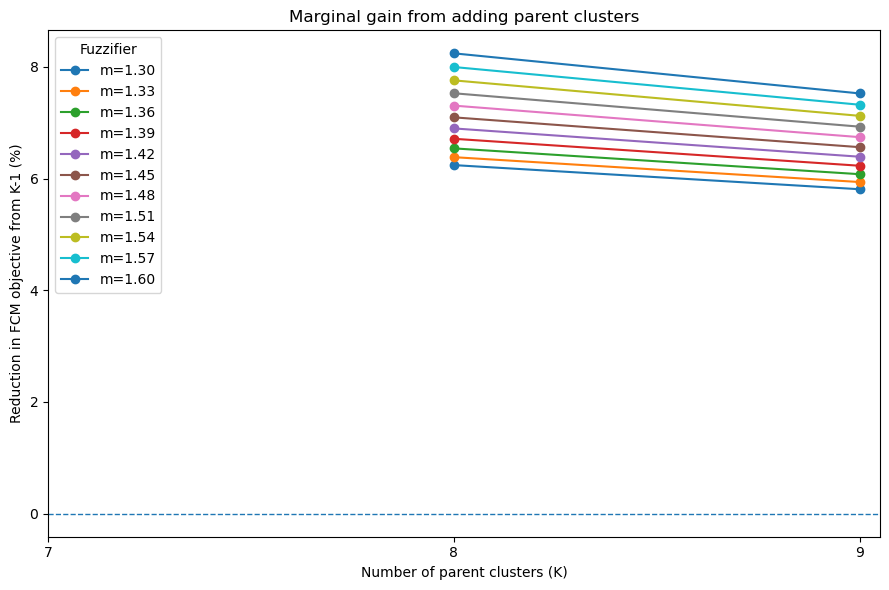

In [22]:
plt.figure(figsize=(9, 6))

for m in M_VALUES:

    sub = validity[
        validity["m"] == m
    ].sort_values("k")

    plt.plot(
        sub["k"],
        sub["objective_gain_pct"],
        marker="o",
        label=f"m={m:.2f}"
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Number of parent clusters (K)")
plt.ylabel("Reduction in FCM objective from K-1 (%)")
plt.title("Marginal gain from adding parent clusters")
plt.xticks(list(K_VALUES))
plt.legend(title="Fuzzifier")
plt.tight_layout()
plt.show()

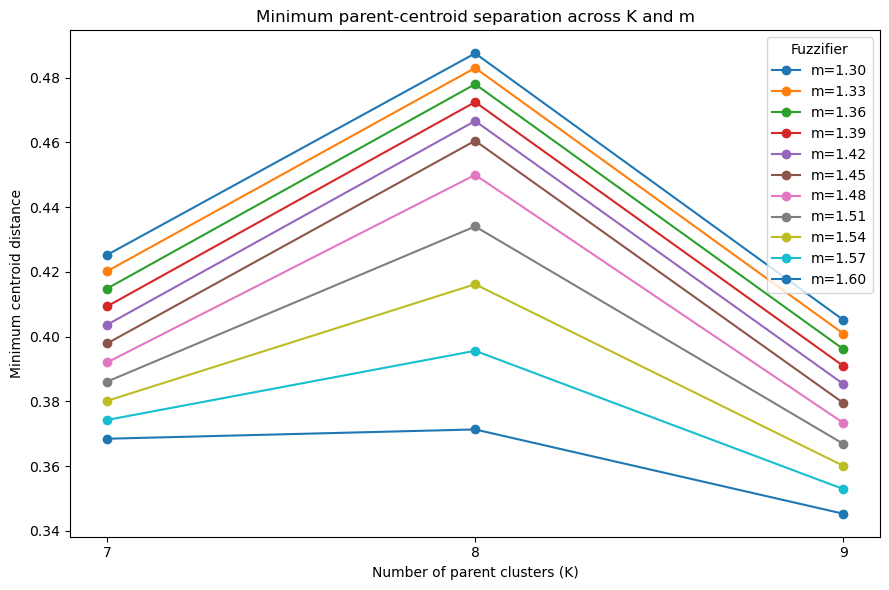

In [23]:
plt.figure(figsize=(9, 6))

for m in M_VALUES:

    sub = validity[
        validity["m"] == m
    ].sort_values("k")

    plt.plot(
        sub["k"],
        sub["min_centroid_distance"],
        marker="o",
        label=f"m={m:.2f}"
    )

plt.xlabel("Number of parent clusters (K)")
plt.ylabel("Minimum centroid distance")
plt.title("Minimum parent-centroid separation across K and m")
plt.xticks(list(K_VALUES))
plt.legend(title="Fuzzifier")
plt.tight_layout()
plt.show()

In [24]:
for metric in [
    "pc",
    "mpc",
    "partition_entropy",
    "xie_beni"
]:

    table = validity.pivot(
        index="m",
        columns="k",
        values=metric
    )

    print(f"\n{metric.upper()}")
    display(table.round(4))


PC


k,7,8,9
m,,,
1.30,0.7090,0.7003,0.6902
1.33,0.6734,0.6637,0.6533
1.36,0.6376,0.6272,0.6165
1.39,0.6021,0.5909,0.5801
1.42,0.5673,0.5553,0.5443
1.45,0.5334,0.5206,0.5096
1.48,0.5005,0.4869,0.4760
1.51,0.4688,0.4544,0.4436
1.54,0.4380,0.4232,0.4127



MPC


k,7,8,9
m,,,
1.30,0.6605,0.6574,0.6514
1.33,0.6189,0.6157,0.6100
1.36,0.5772,0.5739,0.5686
1.39,0.5358,0.5325,0.5276
1.42,0.4952,0.4918,0.4874
1.45,0.4556,0.4521,0.4483
1.48,0.4173,0.4136,0.4105
1.51,0.3802,0.3765,0.3741
1.54,0.3444,0.3408,0.3392



PARTITION_ENTROPY


k,7,8,9
m,,,
1.30,0.6050,0.6356,0.6641
1.33,0.6879,0.7238,0.7559
1.36,0.7707,0.8121,0.8478
1.39,0.8522,0.8994,0.9387
1.42,0.9318,0.9848,1.0277
1.45,1.0090,1.0678,1.1141
1.48,1.0835,1.1478,1.1975
1.51,1.1552,1.2249,1.2777
1.54,1.2243,1.2988,1.3546



XIE_BENI


k,7,8,9
m,,,
1.30,0.9060,0.6464,0.8813
1.33,0.9049,0.6412,0.8751
1.36,0.9031,0.6358,0.8693
1.39,0.9002,0.6304,0.8633
1.42,0.8963,0.6245,0.8569
1.45,0.8913,0.6182,0.8504
1.48,0.8853,0.6229,0.8437
1.51,0.8784,0.6428,0.8372
1.54,0.8704,0.6700,0.8311


we want to minimize Xie-Beni because it is a between cluster dispersion indicator - lower indicates more compact/separated fuzzy partition

In [25]:
# =============================================================================
# FINAL PARENT FCM MODEL
# =============================================================================

K_FINAL = 8
M_FINAL = 1.33

parent_fit = fit_fcm_best_of_n(
    X=X,
    k=K_FINAL,
    m=M_FINAL,
    n_init=N_INIT,
    max_iter=MAX_ITER,
    tol=TOL,
    random_state=RANDOM_STATE
)

parent_centers = parent_fit["centers"]
parent_U = parent_fit["U"]

print(f"K: {K_FINAL}")
print(f"m: {M_FINAL}")
print(f"Best initialization seed: {parent_fit['seed']}")
print(f"Final objective: {parent_fit['objective']:.6f}")
print(f"Iterations: {parent_fit['n_iter']}")

K: 8
m: 1.33
Best initialization seed: 48
Final objective: 175.176128
Iterations: 165


In [26]:
# Highest-membership parent
parent_hard = np.argmax(parent_U, axis=1) + 1

# Highest membership
parent_max_membership = np.max(
    parent_U,
    axis=1
)

# Second-highest membership
parent_second_membership = np.partition(
    parent_U,
    -2,
    axis=1
)[:, -2]

# Difference between first and second parent membership
parent_margin = (
    parent_max_membership
    - parent_second_membership
)

In [27]:
veg_clustered = master.copy()

veg_clustered["parent_cluster"] = parent_hard
veg_clustered["max_membership"] = parent_max_membership
veg_clustered["membership_margin"] = parent_margin

membership_df = pd.DataFrame(
    parent_U,
    columns=[
        f"membership_{i}"
        for i in range(1, K_FINAL + 1)
    ],
    index=veg_clustered.index
)

veg_clustered = pd.concat(
    [veg_clustered, membership_df],
    axis=1
)

In [28]:
# =============================================================================
# REPRODUCE HISTORICAL K=7 PARENT SOLUTION
# =============================================================================

historical_mask = master["Year"] != 2026

hist_compare = master.loc[historical_mask].copy().reset_index(drop=True)

print(f"Historical comparison rows: {len(hist_compare):,}")

Historical comparison rows: 717


In [29]:
hist_X_raw = (
    hist_compare[fg_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
)

hist_row_sums = hist_X_raw.sum(axis=1)

if (hist_row_sums <= 0).any():
    raise ValueError("Historical data contain zero-total FG rows.")

hist_X_prop = hist_X_raw.div(
    hist_row_sums,
    axis=0
)

hist_X = np.sqrt(
    hist_X_prop.to_numpy()
)

In [30]:
OLD_K = 7
OLD_M = 1.50

historical_fit = fit_fcm_best_of_n(
    X=hist_X,
    k=OLD_K,
    m=OLD_M,
    n_init=N_INIT,
    max_iter=MAX_ITER,
    tol=TOL,
    random_state=RANDOM_STATE
)

historical_centers = historical_fit["centers"]

print(f"Historical K: {OLD_K}")
print(f"Historical m: {OLD_M}")
print(f"Historical best seed: {historical_fit['seed']}")
print(f"Historical objective: {historical_fit['objective']:.6f}")

Historical K: 7
Historical m: 1.5
Historical best seed: 44
Historical objective: 90.572382


In [31]:
# =============================================================================
# HISTORICAL ↔ EXPANDED CENTROID MATCHING
# =============================================================================

from scipy.optimize import linear_sum_assignment

centroid_distance = cdist(
    historical_centers,
    parent_centers,
    metric="euclidean"
)

old_idx, new_idx = linear_sum_assignment(
    centroid_distance
)

matches = pd.DataFrame({
    "historical_cluster": old_idx + 1,
    "expanded_cluster": new_idx + 1,
    "hellinger_distance": centroid_distance[
        old_idx,
        new_idx
    ]
})

matches = matches.sort_values(
    "historical_cluster"
).reset_index(drop=True)

display(matches.round(4))

,historical_cluster,expanded_cluster,hellinger_distance
0,1,7,0.2044
1,2,4,0.1156
2,3,3,0.0554
3,4,1,0.1855
4,5,5,0.0486
5,6,2,0.0973
6,7,6,0.1524


In [32]:
matched_new = set(
    matches["expanded_cluster"]
)

all_new = set(
    range(1, K_FINAL + 1)
)

unmatched_new = sorted(
    all_new - matched_new
)

print("Unmatched expanded parent cluster:")
print(unmatched_new)

Unmatched expanded parent cluster:
[8]


In [33]:
def hellinger_centers_to_percent(centers, columns):
    """
    Convert Hellinger-space centroids into closed %
    composition for interpretation.
    """

    squared = centers ** 2

    composition = (
        squared
        / squared.sum(axis=1, keepdims=True)
        * 100
    )

    return pd.DataFrame(
        composition,
        columns=columns
    )

In [34]:
historical_center_fg = hellinger_centers_to_percent(
    historical_centers,
    fg_cols
)

historical_center_fg.index = (
    np.arange(1, OLD_K + 1)
)

historical_center_fg.index.name = "historical_cluster"

In [35]:
expanded_center_fg = hellinger_centers_to_percent(
    parent_centers,
    fg_cols
)

expanded_center_fg.index = (
    np.arange(1, K_FINAL + 1)
)

expanded_center_fg.index.name = "expanded_cluster"

In [36]:
print("Historical centroid compositions:")
display(
    historical_center_fg.round(1)
)

print("Expanded centroid compositions:")
display(
    expanded_center_fg.round(1)
)

Historical centroid compositions:


,ARTR_FG,BAREGROUND_FG,BIOCRUST_FG,EAG_FG,EF_FG,LITTER_FG,NPF_FG,OTHER_FG,PBG_FG,SHRUB_FG
historical_cluster,,,,,,,,,,
1,26.7,26.8,14.1,6.3,0.4,15.9,0.0,0.6,8.4,0.9
2,0.3,4.6,1.2,84.0,3.0,4.6,0.0,0.4,1.5,0.4
3,0.0,35.9,11.7,0.4,38.0,11.7,0.0,0.5,1.7,0.1
4,0.2,25.3,5.0,37.8,1.0,11.5,0.0,0.4,1.4,17.4
5,0.1,30.1,10.6,2.2,1.6,9.6,0.0,0.9,44.3,0.7
6,0.1,24.7,14.5,2.4,0.9,17.8,0.0,0.5,7.3,31.7
7,0.1,15.0,6.4,29.1,1.5,12.1,0.0,0.7,35.0,0.3


Expanded centroid compositions:


,ARTR_FG,BAREGROUND_FG,BIOCRUST_FG,EAG_FG,EF_FG,LITTER_FG,NPF_FG,OTHER_FG,PBG_FG,SHRUB_FG
expanded_cluster,,,,,,,,,,
1,0.8,27.5,2.3,44.8,0.8,16.4,0.0,0.1,0.7,6.5
2,0.1,18.1,19.4,3.8,1.3,16.4,0.0,0.4,6.7,33.8
3,0.0,37.0,11.8,0.9,35.0,14.1,0.0,0.3,0.9,0.1
4,0.1,2.8,0.3,86.8,1.4,7.4,0.0,0.1,1.1,0.2
5,0.1,30.4,8.9,3.0,1.0,11.1,0.0,0.7,44.3,0.6
6,0.1,9.9,3.3,43.5,1.5,11.3,0.0,0.2,30.0,0.2
7,31.3,11.3,23.7,5.9,1.1,13.0,0.0,0.3,12.4,1.0
8,0.3,4.6,9.4,4.5,40.3,14.8,0.0,0.1,26.1,0.0


In [37]:
comparison_rows = []

for _, row in matches.iterrows():

    old_c = int(row["historical_cluster"])
    new_c = int(row["expanded_cluster"])

    old_vals = historical_center_fg.loc[old_c]
    new_vals = expanded_center_fg.loc[new_c]

    record = {
        "historical_cluster": old_c,
        "expanded_cluster": new_c,
        "hellinger_distance": row["hellinger_distance"]
    }

    for fg in fg_cols:
        record[f"{fg}_old"] = old_vals[fg]
        record[f"{fg}_new"] = new_vals[fg]
        record[f"{fg}_change"] = (
            new_vals[fg] - old_vals[fg]
        )

    comparison_rows.append(record)

centroid_comparison = pd.DataFrame(
    comparison_rows
)

In [38]:
display(
    matches
    .sort_values("hellinger_distance")
    .round(4)
)

,historical_cluster,expanded_cluster,hellinger_distance
4,5,5,0.0486
2,3,3,0.0554
5,6,2,0.0973
1,2,4,0.1156
6,7,6,0.1524
3,4,1,0.1855
0,1,7,0.2044


In [39]:
for cid in unmatched_new:

    print(
        f"\nExpanded parent {cid} "
        "(unmatched to historical K=7)"
    )

    print(
        expanded_center_fg
        .loc[cid]
        .sort_values(ascending=False)
        .round(2)
        .to_string()
    )


Expanded parent 8 (unmatched to historical K=7)
EF_FG            40.28
PBG_FG           26.09
LITTER_FG        14.75
BIOCRUST_FG       9.37
BAREGROUND_FG     4.57
EAG_FG            4.52
ARTR_FG           0.31
OTHER_FG          0.08
SHRUB_FG          0.04
NPF_FG            0.00


In [40]:
# =============================================================================
# WHO OCCUPIES THE NEW EIGHTH PARENT?
# =============================================================================

cluster8 = veg_clustered[
    veg_clustered["parent_cluster"] == 8
].copy()

print(f"Expanded cluster 8 n = {len(cluster8):,}")

print("\nBy year:")
print(
    cluster8["Year"]
    .value_counts()
    .sort_index()
)

print("\nProportion by year:")
print(
    cluster8["Year"]
    .value_counts(normalize=True)
    .sort_index()
    .round(3)
)

Expanded cluster 8 n = 107

By year:
Year
2016    19
2018     2
2025     8
2026    78
Name: count, dtype: int64

Proportion by year:
Year
2016    0.178
2018    0.019
2025    0.075
2026    0.729
Name: proportion, dtype: float64


In [41]:
# =============================================================================
# SUMMARY TABLE — FINAL K=8, m=1.33 PARENT SOLUTION
# =============================================================================

# Cluster-level membership / occupancy summaries
cluster_stats = (
    veg_clustered
    .groupby("parent_cluster")
    .agg(
        n=("parent_cluster", "size"),
        mean_membership=("max_membership", "mean"),
        median_membership=("max_membership", "median"),
        mean_margin=("membership_margin", "mean"),
        median_margin=("membership_margin", "median"),
    )
)

cluster_stats["percent_of_plots"] = (
    100 * cluster_stats["n"] / len(veg_clustered)
)

# Put occupancy columns in a useful order
cluster_stats = cluster_stats[
    [
        "n",
        "percent_of_plots",
        "mean_membership",
        "median_membership",
        "mean_margin",
        "median_margin",
    ]
]


# =============================================================================
# CENTROID FG COMPOSITION
# =============================================================================

# expanded_center_fg is already back-transformed from Hellinger space to %
centroid_table = expanded_center_fg.copy()

# Put FG dimensions in an ecologically readable order
fg_order = [
    "ARTR_FG",
    "SHRUB_FG",
    "PBG_FG",
    "EAG_FG",
    "EF_FG",
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "LITTER_FG",
    "OTHER_FG",
    "NPF_FG",
]

centroid_table = centroid_table[fg_order]

# Cleaner display names
centroid_table = centroid_table.rename(
    columns={
        "ARTR_FG": "ARTR",
        "SHRUB_FG": "Shrub",
        "PBG_FG": "PBG",
        "EAG_FG": "EAG",
        "EF_FG": "EF",
        "BAREGROUND_FG": "Bare",
        "BIOCRUST_FG": "Biocrust",
        "LITTER_FG": "Litter",
        "OTHER_FG": "Other",
        "NPF_FG": "NPF",
    }
)


# =============================================================================
# COMBINE
# =============================================================================

parent_summary = cluster_stats.join(
    centroid_table,
    how="left"
)

parent_summary.index.name = "Parent"

# Appropriate display precision
display_table = parent_summary.copy()

display_table["percent_of_plots"] = (
    display_table["percent_of_plots"].round(1)
)

for c in [
    "mean_membership",
    "median_membership",
    "mean_margin",
    "median_margin",
]:
    display_table[c] = display_table[c].round(3)

for c in centroid_table.columns:
    display_table[c] = display_table[c].round(1)

display(display_table)

,n,percent_of_plots,mean_membership,median_membership,mean_margin,median_margin,ARTR,Shrub,PBG,EAG,EF,Bare,Biocrust,Litter,Other,NPF
Parent,,,,,,,,,,,,,,,,
1,178,15.2,0.687,0.696,0.514,0.496,0.8,6.5,0.7,44.8,0.8,27.5,2.3,16.4,0.1,0.0
2,139,11.9,0.795,0.866,0.700,0.809,0.1,33.8,6.7,3.8,1.3,18.1,19.4,16.4,0.4,0.0
3,128,10.9,0.759,0.853,0.637,0.776,0.0,0.1,0.9,0.9,35.0,37.0,11.8,14.1,0.3,0.0
4,220,18.8,0.850,0.949,0.752,0.908,0.1,0.2,1.1,86.8,1.4,2.8,0.3,7.4,0.1,0.0
5,146,12.5,0.752,0.792,0.627,0.708,0.1,0.6,44.3,3.0,1.0,30.4,8.9,11.1,0.7,0.0
6,129,11.0,0.754,0.789,0.608,0.656,0.1,0.2,30.0,43.5,1.5,9.9,3.3,11.3,0.2,0.0
7,124,10.6,0.738,0.786,0.621,0.707,31.3,1.0,12.4,5.9,1.1,11.3,23.7,13.0,0.3,0.0
8,107,9.1,0.733,0.746,0.589,0.632,0.3,0.0,26.1,4.5,40.3,4.6,9.4,14.8,0.1,0.0


In [42]:
publication_table = parent_summary[
    [
        "n",
        "percent_of_plots",
        "mean_membership",
        "median_membership",
        "median_margin",
        "ARTR",
        "Shrub",
        "PBG",
        "EAG",
        "EF",
        "Bare",
        "Biocrust",
        "Litter",
        "Other",
        "NPF",
    ]
].copy()

publication_table = publication_table.rename(
    columns={
        "percent_of_plots": "% plots",
        "mean_membership": "Mean membership",
        "median_membership": "Median membership",
        "median_margin": "Median margin",
    }
)

display(publication_table.round({
    "% plots": 1,
    "Mean membership": 3,
    "Median membership": 3,
    "Median margin": 3,
    "ARTR": 1,
    "Shrub": 1,
    "PBG": 1,
    "EAG": 1,
    "EF": 1,
    "Bare": 1,
    "Biocrust": 1,
    "Litter": 1,
    "Other": 1,
    "NPF": 1,
}))

,n,% plots,Mean membership,Median membership,Median margin,ARTR,Shrub,PBG,EAG,EF,Bare,Biocrust,Litter,Other,NPF
Parent,,,,,,,,,,,,,,,
1,178,15.2,0.687,0.696,0.496,0.8,6.5,0.7,44.8,0.8,27.5,2.3,16.4,0.1,0.0
2,139,11.9,0.795,0.866,0.809,0.1,33.8,6.7,3.8,1.3,18.1,19.4,16.4,0.4,0.0
3,128,10.9,0.759,0.853,0.776,0.0,0.1,0.9,0.9,35.0,37.0,11.8,14.1,0.3,0.0
4,220,18.8,0.850,0.949,0.908,0.1,0.2,1.1,86.8,1.4,2.8,0.3,7.4,0.1,0.0
5,146,12.5,0.752,0.792,0.708,0.1,0.6,44.3,3.0,1.0,30.4,8.9,11.1,0.7,0.0
6,129,11.0,0.754,0.789,0.656,0.1,0.2,30.0,43.5,1.5,9.9,3.3,11.3,0.2,0.0
7,124,10.6,0.738,0.786,0.707,31.3,1.0,12.4,5.9,1.1,11.3,23.7,13.0,0.3,0.0
8,107,9.1,0.733,0.746,0.632,0.3,0.0,26.1,4.5,40.3,4.6,9.4,14.8,0.1,0.0


In [43]:
# =============================================================================
# SPECIES-LEVEL VARIABLES FOR NESTED SUBCLUSTERING
# =============================================================================

meta_cols = {
    "X",
    "Plot",
    "Year",
    "total_cover",
    "total_cover_fg",
    "SHRUB_total",
    "parent_cluster",
    "max_membership",
    "membership_margin",
}

fg_cols = [
    c for c in veg_clustered.columns
    if c.endswith("_FG")
]

membership_cols = [
    c for c in veg_clustered.columns
    if c.startswith("membership_")
]

# Explicit non-vegetation surface observations.
# These are excluded because surface structure is already represented
# in the parent FG solution.
surface_cols = {
    "BAREGROUND",
    "BIOCRUST",
    "LITTER",
    "ROCK",
    "SHIT",
    "TRASH",
}

species_cols = [
    c for c in veg_clustered.columns
    if c not in meta_cols
    and c not in fg_cols
    and c not in membership_cols
    and c not in surface_cols
    and not c.endswith("_total")
]

print(f"Species / vegetation-catchall columns: {len(species_cols)}")
print(species_cols)

Species / vegetation-catchall columns: 80
['ARTR2', 'CHVI8', 'ERNA10', 'KRLA2', 'ATCO', 'PUTR2', 'BAPR5', 'POSE', 'BRTE', 'AGCR', 'PSSP6', 'ACTH7', 'HECO', 'ELEL5', 'ACHY', 'ELYMUS', 'GRSP', 'GUSA', 'SAVE4', 'SHRUB', 'BRBR', 'PBG', 'ONAC', 'CHJU', 'FORB', 'BRASS', 'SATR12D', 'CETE5', 'LEPE2', 'NOTR', 'UNK.PLANT', 'OTHER', 'BASC', 'SATR12', 'HEAN3', 'SIAL2D', 'LASE', 'SIAL2', 'CEST8', 'CHVI8D', 'DESO2', 'VUOC', 'ARTR2D', 'AMAL', 'TEGL', 'BAPR5D', 'LECI4', 'EPBR3', 'DEPI', 'TACA8', 'CREPI', 'FEID', 'EUMA7', 'ATCA2', 'SPGR2', 'PSJU3', 'BAAM4', 'TRDU', 'MACA2', 'GAYOP', 'SPCR', 'TRMA3', 'ATCOD', 'VUBR', 'TESP2', 'ATCA2D', 'BASA3', 'AMAC2', 'ARAR8', 'CADR', 'CICY', 'DISP', 'ERCI6', 'ERTR13', 'HAGL', 'PHHA', 'PHLO2', 'PIDE4', 'PSLA3', 'VULPI']


In [44]:
# =============================================================================
# FUZZY MEMBERSHIP-WEIGHTED SPECIES COMPOSITION BY PARENT
# =============================================================================

species_matrix = (
    veg_clustered[species_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
)

weighted_species = []

for parent in range(1, K_FINAL + 1):

    w = parent_U[:, parent - 1]

    weighted_mean = (
        species_matrix
        .multiply(w, axis=0)
        .sum(axis=0)
        / w.sum()
    )

    row = {
        "parent_cluster": parent,
        **weighted_mean.to_dict()
    }

    weighted_species.append(row)

weighted_species = (
    pd.DataFrame(weighted_species)
    .set_index("parent_cluster")
)

for parent in range(1, K_FINAL + 1):

    print("\n" + "=" * 70)
    print(f"PARENT {parent}")
    print("=" * 70)

    print(
        weighted_species
        .loc[parent]
        .sort_values(ascending=False)
        .head(15)
        .round(2)
        .to_string()
    )


PARENT 1
BRTE       36.74
CHVI8       3.54
ARTR2       3.25
POSE        1.49
ATCO        1.37
SAVE4       1.22
ERNA10      0.88
ATCA2       0.75
SATR12D     0.73
KRLA2       0.73
BRASS       0.65
ERTR13      0.58
AGCR        0.57
SATR12      0.57
SIAL2       0.43

PARENT 2
CHVI8      13.03
KRLA2       8.31
BRTE        6.39
POSE        5.03
ATCO        2.91
ARTR2       1.50
SAVE4       1.27
SATR12D     1.23
PBG         1.21
CETE5       0.91
AGCR        0.79
PSSP6       0.66
SIAL2       0.66
VULPI       0.61
OTHER       0.57

PARENT 3
BAPR5      9.20
CETE5      5.44
BRASS      4.14
SATR12     3.52
BRTE       3.51
LEPE2      2.97
SIAL2      2.97
POSE       2.40
ARTR2      1.15
SATR12D    0.68
AGCR       0.59
OTHER      0.44
KRLA2      0.42
DESO2      0.41
CHVI8      0.37

PARENT 4
BRTE       73.89
POSE        1.74
BRASS       1.41
ARTR2       1.33
CHVI8       0.67
AGCR        0.65
SIAL2       0.53
SATR12      0.46
SATR12D     0.42
BAPR5       0.38
CETE5       0.30
ERNA10      0.24
OTHER 

In [45]:
# =============================================================================
# CORE-MEMBERSHIP THRESHOLD SENSITIVITY
# =============================================================================

core_thresholds = [
    0.50,
    0.55,
    0.60,
    0.65,
    0.70,
]

core_rows = []

for parent in range(1, K_FINAL + 1):

    parent_mask = (
        veg_clustered["parent_cluster"] == parent
    )

    parent_n = parent_mask.sum()

    for threshold in core_thresholds:

        core_mask = (
            parent_mask
            & (veg_clustered["max_membership"] >= threshold)
        )

        n_core = core_mask.sum()

        core_rows.append({
            "parent": parent,
            "threshold": threshold,
            "n_parent": parent_n,
            "n_core": n_core,
            "percent_retained": 100 * n_core / parent_n,
        })


core_sensitivity = pd.DataFrame(core_rows)

display(
    core_sensitivity
    .pivot(
        index="parent",
        columns="threshold",
        values="n_core"
    )
)

display(
    core_sensitivity
    .pivot(
        index="parent",
        columns="threshold",
        values="percent_retained"
    )
    .round(1)
)

threshold,0.50,0.55,0.60,0.65,0.70
parent,,,,,
1,138,122,114,97,89
2,123,119,113,109,102
3,103,99,91,83,79
4,203,193,187,183,175
5,121,111,106,100,91
6,108,104,97,91,81
7,104,97,91,88,80
8,88,79,75,66,61


threshold,0.50,0.55,0.60,0.65,0.70
parent,,,,,
1,77.5,68.5,64.0,54.5,50.0
2,88.5,85.6,81.3,78.4,73.4
3,80.5,77.3,71.1,64.8,61.7
4,92.3,87.7,85.0,83.2,79.5
5,82.9,76.0,72.6,68.5,62.3
6,83.7,80.6,75.2,70.5,62.8
7,83.9,78.2,73.4,71.0,64.5
8,82.2,73.8,70.1,61.7,57.0


In [46]:
# =============================================================================
# SPECIES HELLINGER TRANSFORM
# =============================================================================

def species_hellinger(df_sub, species_cols):

    X_species_raw = (
        df_sub[species_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
    )

    row_sums = X_species_raw.sum(axis=1)

    keep = row_sums > 0

    X_species_raw = (
        X_species_raw
        .loc[keep]
        .copy()
    )

    row_sums = row_sums.loc[keep]

    X_species_prop = (
        X_species_raw
        .div(row_sums, axis=0)
    )

    X_species_hell = np.sqrt(
        X_species_prop.to_numpy()
    )

    return (
        X_species_hell,
        X_species_raw.index
    )

In [47]:
SUB_K_VALUES = range(2, 7)
CORE_MEMBERSHIP = 0.60

In [48]:
# =============================================================================
# SPECIES SUBCLUSTER DIAGNOSTICS WITHIN EACH PARENT
# =============================================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

SUB_K_VALUES = range(2, 7)
RANDOM_STATE = 42
N_INIT_SUB = 50

subcluster_results = []
subcluster_fits = {}

for parent in range(1, K_FINAL + 1):

    parent_core = veg_clustered[
        (veg_clustered["parent_cluster"] == parent)
        &
        (veg_clustered["max_membership"] >= CORE_MEMBERSHIP)
    ].copy()

    X_species, kept_idx = species_hellinger(
        parent_core,
        species_cols
    )

    parent_core = parent_core.loc[kept_idx].copy()

    print("\n" + "=" * 75)
    print(
        f"PARENT {parent} | "
        f"core n = {len(parent_core)}"
    )
    print("=" * 75)

    if len(parent_core) < 10:
        print("Too few observations for subclustering.")
        continue

    for k in SUB_K_VALUES:

        if len(parent_core) <= k:
            continue

        km = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=N_INIT_SUB,
            max_iter=1000
        )

        labels = km.fit_predict(
            X_species
        )

        counts = pd.Series(
            labels
        ).value_counts()

        silhouette = silhouette_score(
            X_species,
            labels,
            metric="euclidean"
        )

        subcluster_results.append({
            "parent": parent,
            "k": k,
            "n_core": len(parent_core),
            "silhouette": silhouette,
            "min_subcluster_n": counts.min(),
            "max_subcluster_n": counts.max(),
        })

        subcluster_fits[(parent, k)] = {
            "model": km,
            "labels": labels,
            "index": kept_idx,
            "X": X_species,
        }

        print(
            f"k={k} | "
            f"silhouette={silhouette:.3f} | "
            f"min n={counts.min():3d} | "
            f"max n={counts.max():3d}"
        )


subcluster_diagnostics = pd.DataFrame(
    subcluster_results
)


PARENT 1 | core n = 114
k=2 | silhouette=0.254 | min n= 17 | max n= 97


c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\scottfordham\AppData\Local\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\scottfordham\AppData\Local\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_chil

k=3 | silhouette=0.198 | min n= 17 | max n= 74
k=4 | silhouette=0.218 | min n= 15 | max n= 63


c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=5 | silhouette=0.248 | min n=  8 | max n= 58
k=6 | silhouette=0.263 | min n=  2 | max n= 56

PARENT 2 | core n = 113


...

c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=3 | silhouette=0.256 | min n= 17 | max n= 40
k=4 | silhouette=0.285 | min n=  6 | max n= 33


c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=5 | silhouette=0.306 | min n=  6 | max n= 32
k=6 | silhouette=0.308 | min n=  6 | max n= 30


c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [49]:
# =============================================================================
# SPECIES SUBCLUSTER DIAGNOSTICS
# =============================================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

SUB_K_VALUES = range(1, 7)
N_INIT_SUB = 50
RANDOM_STATE = 42

subcluster_results = []
subcluster_fits = {}

for parent in range(1, K_FINAL + 1):

    parent_core = veg_clustered[
        (veg_clustered["parent_cluster"] == parent)
        &
        (veg_clustered["max_membership"] >= CORE_MEMBERSHIP)
    ].copy()

    X_species, kept_idx = species_hellinger(
        parent_core,
        species_cols
    )

    parent_core = parent_core.loc[kept_idx].copy()

    print("\n" + "=" * 75)
    print(
        f"PARENT {parent} | "
        f"core n = {len(parent_core)}"
    )
    print("=" * 75)

    for k in SUB_K_VALUES:

        if len(parent_core) <= k:
            continue

        km = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=N_INIT_SUB,
            max_iter=1000
        )

        labels = km.fit_predict(X_species)

        counts = (
            pd.Series(labels)
            .value_counts()
        )

        # silhouette is undefined for k = 1
        if k == 1:
            sil = np.nan
        else:
            sil = silhouette_score(
                X_species,
                labels,
                metric="euclidean"
            )

        subcluster_results.append({
            "parent": parent,
            "k": k,
            "n_core": len(parent_core),
            "inertia": km.inertia_,
            "silhouette": sil,
            "min_subcluster_n": counts.min(),
            "max_subcluster_n": counts.max(),
        })

        subcluster_fits[(parent, k)] = {
            "model": km,
            "labels": labels,
            "index": kept_idx,
            "X": X_species,
        }

        if k == 1:
            print(
                f"k={k} | "
                f"inertia={km.inertia_:.3f}"
            )
        else:
            print(
                f"k={k} | "
                f"inertia={km.inertia_:.3f} | "
                f"silhouette={sil:.3f} | "
                f"min n={counts.min():3d}"
            )

subcluster_diagnostics = pd.DataFrame(
    subcluster_results
)


PARENT 1 | core n = 114


c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=1 | inertia=29.731


c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=2 | inertia=24.437 | silhouette=0.254 | min n= 17


...

c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=3 | inertia=23.037 | silhouette=0.256 | min n= 17
k=4 | inertia=19.071 | silhouette=0.285 | min n=  6


c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=5 | inertia=16.689 | silhouette=0.306 | min n=  6
k=6 | inertia=14.827 | silhouette=0.308 | min n=  6


c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [50]:
subcluster_diagnostics = (
    subcluster_diagnostics
    .sort_values(["parent", "k"])
    .reset_index(drop=True)
)

subcluster_diagnostics["inertia_gain_pct"] = (
    subcluster_diagnostics
    .groupby("parent")["inertia"]
    .transform(
        lambda s: 100 * (s.shift(1) - s) / s.shift(1)
    )
)

In [51]:
display(
    subcluster_diagnostics[
        [
            "parent",
            "k",
            "n_core",
            "inertia",
            "inertia_gain_pct",
            "silhouette",
            "min_subcluster_n",
        ]
    ].round(3)
)

,parent,k,n_core,inertia,inertia_gain_pct,silhouette,min_subcluster_n
0,1,1,114,29.731,NaN,NaN,114
1,1,2,114,24.437,17.807,0.254,17
2,1,3,114,21.170,13.368,0.198,17
3,1,4,114,18.927,10.595,0.218,15
4,1,5,114,16.787,11.305,0.248,8
5,1,6,114,15.374,8.417,0.263,2
6,2,1,113,73.259,NaN,NaN,113
7,2,2,113,43.880,40.103,0.385,55
8,2,3,113,30.618,30.224,0.458,20
9,2,4,113,25.837,15.615,0.486,4


In [52]:
display(
    subcluster_diagnostics
    .pivot(
        index="parent",
        columns="k",
        values="silhouette"
    )
    .round(3)
)

k,1,2,3,4,5,6
parent,,,,,,
1,NaN,0.254,0.198,0.218,0.248,0.263
2,NaN,0.385,0.458,0.486,0.348,0.242
3,NaN,0.322,0.376,0.442,0.454,0.485
4,NaN,0.361,0.190,0.221,0.240,0.258
5,NaN,0.276,0.372,0.414,0.437,0.450
6,NaN,0.266,0.325,0.355,0.369,0.397
7,NaN,0.213,0.211,0.228,0.187,0.209
8,NaN,0.227,0.256,0.285,0.306,0.308


In [53]:
display(
    subcluster_diagnostics
    .pivot(
        index="parent",
        columns="k",
        values="inertia_gain_pct"
    )
    .round(1)
)

k,1,2,3,4,5,6
parent,,,,,,
1,NaN,17.8,13.4,10.6,11.3,8.4
2,NaN,40.1,30.2,15.6,9.4,7.9
3,NaN,31.7,20.4,23.4,22.3,20.4
4,NaN,15.2,11.4,10.6,8.6,9.1
5,NaN,27.5,29.1,19.3,16.2,12.0
6,NaN,26.6,19.1,11.5,12.8,12.9
7,NaN,22.3,14.5,8.8,8.4,7.9
8,NaN,18.2,18.1,17.2,12.5,11.2


In [54]:
def show_subcluster_composition(parent, k, top_n=12):

    fit = subcluster_fits[(parent, k)]

    centers_h = fit["model"].cluster_centers_
    labels = fit["labels"]

    # Back-transform Hellinger centroids
    centers_sq = centers_h ** 2
    centers_prop = (
        centers_sq
        / centers_sq.sum(axis=1, keepdims=True)
    )

    counts = np.bincount(
        labels,
        minlength=k
    )

    print("\n" + "=" * 80)
    print(f"PARENT {parent} | k = {k}")
    print("=" * 80)

    for sub in range(k):

        composition = pd.Series(
            centers_prop[sub] * 100,
            index=species_cols
        ).sort_values(ascending=False)

        print(
            f"\n--- Subcluster {sub + 1} "
            f"| n = {counts[sub]} ---"
        )

        print(
            composition
            .head(top_n)
            .round(1)
            .to_string()
        )

In [55]:
show_subcluster_composition(2, 3)

show_subcluster_composition(3, 4)
show_subcluster_composition(3, 5)
show_subcluster_composition(3, 6)

show_subcluster_composition(4, 2)

show_subcluster_composition(5, 3)
show_subcluster_composition(5, 4)

show_subcluster_composition(6, 3)

show_subcluster_composition(8, 3)


PARENT 2 | k = 3

--- Subcluster 1 | n = 55 ---
CHVI8      81.5
BRTE        7.9
POSE        3.4
PBG         3.2
SATR12D     1.5
OTHER       0.8
PSSP6       0.7
AGCR        0.3
BRASS       0.2
CETE5       0.1
ELEL5       0.1
ELYMUS      0.1

--- Subcluster 2 | n = 38 ---
KRLA2      84.7
POSE        9.6
BRTE        1.4
VULPI       1.3
SIAL2       0.8
DESO2       0.4
CETE5       0.4
SATR12D     0.4
BRASS       0.3
DEPI        0.2
OTHER       0.2
PBG         0.2

--- Subcluster 3 | n = 20 ---
ATCO         73.0
BRTE          7.2
SAVE4         5.7
POSE          5.5
CETE5         3.5
SIAL2         1.5
KRLA2         1.1
BRASS         0.6
UNK.PLANT     0.4
SATR12D       0.2
EUMA7         0.2
ARTR2         0.2

PARENT 3 | k = 4

--- Subcluster 1 | n = 10 ---
BRASS      93.3
CETE5       2.0
BRTE        1.5
OTHER       1.3
SATR12D     0.9
ATCO        0.4
AGCR        0.3
PBG         0.2
FORB        0.1
BAPR5       0.0
POSE        0.0
SIAL2       0.0

--- Subcluster 2 | n = 29 ---
SATR12     47.0
C

In [56]:
def show_subcluster_years(parent, k):

    fit = subcluster_fits[(parent, k)]

    out = veg_clustered.loc[
        fit["index"],
        ["Year"]
    ].copy()

    out["subcluster"] = (
        fit["labels"] + 1
    )

    counts = pd.crosstab(
        out["subcluster"],
        out["Year"]
    )

    props = pd.crosstab(
        out["subcluster"],
        out["Year"],
        normalize="index"
    ) * 100

    print("\n" + "=" * 70)
    print(f"PARENT {parent} | k={k} | YEAR COUNTS")
    print("=" * 70)

    display(counts)

    print("\nWithin-subcluster %:")
    display(props.round(1))

In [57]:
show_subcluster_years(2, 3)

show_subcluster_years(3, 5)
show_subcluster_years(3, 6)

show_subcluster_years(5, 3)

show_subcluster_years(6, 3)

show_subcluster_years(8, 3)


PARENT 2 | k=3 | YEAR COUNTS


Year,2016,2018,2025,2026
subcluster,,,,
1,22,31,1,1
2,10,5,5,18
3,6,1,6,7



Within-subcluster %:


Year,2016,2018,2025,2026
subcluster,,,,
1,40.0,56.4,1.8,1.8
2,26.3,13.2,13.2,47.4
3,30.0,5.0,30.0,35.0



PARENT 3 | k=5 | YEAR COUNTS


...

Year,2016,2018,2025,2026
subcluster,,,,
1,45.8,25.0,20.8,8.3
2,38.5,23.1,15.4,23.1
3,5.9,5.9,2.9,85.3



PARENT 8 | k=3 | YEAR COUNTS


Year,2016,2018,2025,2026
subcluster,,,,
1,8,1,5,4
2,0,0,1,39
3,4,0,0,13



Within-subcluster %:


Year,2016,2018,2025,2026
subcluster,,,,
1,44.4,5.6,27.8,22.2
2,0.0,0.0,2.5,97.5
3,23.5,0.0,0.0,76.5


In [58]:
# =============================================================================
# PROVISIONAL STATE LIBRARY + MEAN OBSERVED FG COVER
# =============================================================================

CORE_MEMBERSHIP = 0.60

# Final number of taxonomic subclusters retained within each parent.
# Parent 8 was fit at k=3, but raw subclusters 1 and 2 are merged below.
FINAL_SUB_K = {
    1: 1,
    2: 3,
    3: 5,
    4: 1,
    5: 3,
    6: 3,
    7: 1,
    8: 3,
}

PARENT_LABELS = {
    1: "BRTE annual-grass / shrub-bare mix",
    2: "Non-ARTR shrub",
    3: "EF-bare annual-forb",
    4: "Extreme BRTE / EAG",
    5: "Open perennial bunchgrass",
    6: "BRTE-PBG codominant",
    7: "ARTR shrub-steppe",
    8: "EF-PBG codominant",
}

# Mapping from (parent, raw KMeans subcluster) -> final state
# Note: KMeans labels shown previously were +1.
STATE_MAP = {
    (1, 1): ("1.1", "BRTE-dominated mixed annual grass"),

    (2, 1): ("2.1", "CHVI8 shrub"),
    (2, 2): ("2.2", "KRLA2 shrub"),
    (2, 3): ("2.3", "ATCO shrub"),

    (3, 1): ("3.1", "BRASS annual forb"),
    (3, 2): ("3.2", "BAPR5 annual forb"),
    (3, 3): ("3.3", "CETE5 annual forb"),
    (3, 4): ("3.4", "SATR12-SIAL2 annual forb"),
    (3, 5): ("3.5", "LEPE2 annual forb"),

    (4, 1): ("4.1", "BRTE endmember"),

    (5, 1): ("5.1", "Mixed PBG-PSSP6-ACTH7"),
    (5, 2): ("5.2", "POSE perennial grass"),
    (5, 3): ("5.3", "AGCR perennial grass"),

    (6, 1): ("6.1", "BRTE-PSSP6/PBG"),
    (6, 2): ("6.2", "BRTE-AGCR"),
    (6, 3): ("6.3", "BRTE-POSE"),

    (7, 1): ("7.1", "ARTR2-POSE shrub-steppe"),

    # Collapse raw P8 subclusters 1 and 2
    (8, 1): ("8.1", "POSE-mustard/annual-forb"),
    (8, 2): ("8.1", "POSE-mustard/annual-forb"),
    (8, 3): ("8.2", "POSE-BAPR5"),
}


# -----------------------------------------------------------------------------
# Core plots
# -----------------------------------------------------------------------------

core_states = veg_clustered[
    veg_clustered["max_membership"] >= CORE_MEMBERSHIP
].copy()

core_states["raw_subcluster"] = 1


# -----------------------------------------------------------------------------
# Attach selected KMeans assignments for split parents
# -----------------------------------------------------------------------------

for parent, k in FINAL_SUB_K.items():

    if k == 1:
        continue

    fit = subcluster_fits[(parent, k)]

    idx = fit["index"]
    labels = fit["labels"] + 1

    core_states.loc[idx, "raw_subcluster"] = labels


core_states["raw_subcluster"] = (
    core_states["raw_subcluster"].astype(int)
)


# -----------------------------------------------------------------------------
# Map to final state IDs and labels
# -----------------------------------------------------------------------------

core_states["state_id"] = [
    STATE_MAP[(p, s)][0]
    for p, s in zip(
        core_states["parent_cluster"],
        core_states["raw_subcluster"]
    )
]

core_states["state_label"] = [
    STATE_MAP[(p, s)][1]
    for p, s in zip(
        core_states["parent_cluster"],
        core_states["raw_subcluster"]
    )
]

core_states["parent_label"] = (
    core_states["parent_cluster"]
    .map(PARENT_LABELS)
)


# -----------------------------------------------------------------------------
# Mean observed FG cover
# -----------------------------------------------------------------------------

fg_order = [
    "ARTR_FG",
    "SHRUB_FG",
    "PBG_FG",
    "EAG_FG",
    "EF_FG",
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "LITTER_FG",
    "OTHER_FG",
    "NPF_FG",
]

fg_display = {
    "ARTR_FG": "ARTR",
    "SHRUB_FG": "Shrub",
    "PBG_FG": "PBG",
    "EAG_FG": "EAG",
    "EF_FG": "EF",
    "BAREGROUND_FG": "Bare",
    "BIOCRUST_FG": "Biocrust",
    "LITTER_FG": "Litter",
    "OTHER_FG": "Other",
    "NPF_FG": "NPF",
}

state_summary = (
    core_states
    .groupby(
        [
            "parent_cluster",
            "parent_label",
            "state_id",
            "state_label",
        ],
        sort=False,
        observed=True
    )
    .agg(
        n_core=("state_id", "size"),
        **{
            fg_display[c]: (c, "mean")
            for c in fg_order
        }
    )
    .reset_index()
)

# State IDs sort properly as numbers such as 3.5, 8.1, etc.
state_summary["_sort"] = (
    state_summary["state_id"].astype(float)
)

state_summary = (
    state_summary
    .sort_values("_sort")
    .drop(columns="_sort")
    .reset_index(drop=True)
)

display(
    state_summary.round(1)
)

print(
    f"Final provisional states: "
    f"{state_summary['state_id'].nunique()}"
)

print(
    f"Core plots represented: "
    f"{state_summary['n_core'].sum()}"
)

,parent_cluster,parent_label,state_id,state_label,n_core,ARTR,Shrub,PBG,EAG,EF,Bare,Biocrust,Litter,Other,NPF
0,1,BRTE annual-grass / shrub-bare mix,1.1,BRTE-dominated mixed annual grass,114,2.3,9.9,0.7,40.0,1.1,26.7,3.7,15.0,0.5,0.0
1,2,Non-ARTR shrub,2.1,CHVI8 shrub,55,0.1,35.1,9.5,5.2,0.9,16.9,12.0,19.3,1.0,0.0
2,2,Non-ARTR shrub,2.2,KRLA2 shrub,38,0.1,29.5,6.4,3.4,2.8,16.2,27.7,13.2,0.3,0.5
3,2,Non-ARTR shrub,2.3,ATCO shrub,20,0.6,29.3,3.9,3.8,4.6,15.5,27.9,13.2,1.2,0.0
4,3,EF-bare annual-forb,3.1,BRASS annual forb,10,0.0,0.5,1.5,1.8,41.7,35.4,12.1,6.3,0.7,0.0
5,3,EF-bare annual-forb,3.2,BAPR5 annual forb,37,0.0,0.3,2.7,1.0,29.7,31.5,19.8,14.0,1.0,0.0
6,3,EF-bare annual-forb,3.3,CETE5 annual forb,12,0.0,0.0,2.0,0.9,42.4,38.4,8.6,6.8,0.8,0.0
7,3,EF-bare annual-forb,3.4,SATR12-SIAL2 annual forb,19,0.0,0.2,1.5,1.8,32.2,33.7,11.4,18.9,0.2,0.0
8,3,EF-bare annual-forb,3.5,LEPE2 annual forb,13,0.0,0.1,0.8,2.8,30.1,38.5,9.5,17.1,1.1,0.0
9,4,Extreme BRTE / EAG,4.1,BRTE endmember,187,0.7,1.0,2.1,80.4,3.0,3.0,0.9,8.5,0.3,0.0


Final provisional states: 19
Core plots represented: 874


In [59]:
# =============================================================================
# PROPAGATE FINAL SPECIES STATES TO ALL 1,171 PLOTS
# =============================================================================

CORE_MEMBERSHIP = 0.60

# Species K used to define each parent.
# Parent 8 retains the k=3 fitted solution internally,
# but raw subclusters 1 and 2 are collapsed into final state 8.1.
FINAL_SUB_K = {
    1: 1,
    2: 3,
    3: 5,
    4: 1,
    5: 3,
    6: 3,
    7: 1,
    8: 3,
}


PARENT_LABELS = {
    1: "BRTE annual-grass / shrub-bare mix",
    2: "Non-ARTR shrub",
    3: "EF-bare annual-forb",
    4: "Extreme BRTE / EAG",
    5: "Open perennial bunchgrass",
    6: "BRTE-PBG codominant",
    7: "ARTR shrub-steppe",
    8: "EF-PBG codominant",
}


# (parent, raw KMeans subcluster) -> (final state ID, final state label)
STATE_MAP = {
    (1, 1): ("1.1", "BRTE-dominated mixed annual grass"),

    (2, 1): ("2.1", "CHVI8 shrub"),
    (2, 2): ("2.2", "KRLA2 shrub"),
    (2, 3): ("2.3", "ATCO shrub"),

    (3, 1): ("3.1", "BRASS annual forb"),
    (3, 2): ("3.2", "BAPR5 annual forb"),
    (3, 3): ("3.3", "CETE5 annual forb"),
    (3, 4): ("3.4", "SATR12-SIAL2 annual forb"),
    (3, 5): ("3.5", "LEPE2 annual forb"),

    (4, 1): ("4.1", "BRTE endmember"),

    (5, 1): ("5.1", "Mixed PBG-PSSP6-ACTH7"),
    (5, 2): ("5.2", "POSE perennial grass"),
    (5, 3): ("5.3", "AGCR perennial grass"),

    (6, 1): ("6.1", "BRTE-PSSP6/PBG"),
    (6, 2): ("6.2", "BRTE-AGCR"),
    (6, 3): ("6.3", "BRTE-POSE"),

    (7, 1): ("7.1", "ARTR2-POSE shrub-steppe"),

    # Parent 8: raw 1 + raw 2 collapsed
    (8, 1): ("8.1", "POSE-mustard/annual-forb"),
    (8, 2): ("8.1", "POSE-mustard/annual-forb"),
    (8, 3): ("8.2", "POSE-BAPR5"),
}


# -----------------------------------------------------------------------------
# Start with every plot
# -----------------------------------------------------------------------------

veg_states = veg_clustered.copy()

veg_states["is_reference"] = (
    veg_states["max_membership"] >= CORE_MEMBERSHIP
)

veg_states["parent_label"] = (
    veg_states["parent_cluster"]
    .map(PARENT_LABELS)
)

veg_states["raw_subcluster"] = np.nan
veg_states["state_id"] = pd.NA
veg_states["state_label"] = pd.NA

# Useful QA field
veg_states["species_total"] = (
    veg_states[species_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
    .sum(axis=1)
)


# =============================================================================
# ASSIGN WITHIN EACH DOMINANT PARENT
# =============================================================================

for parent in range(1, K_FINAL + 1):

    idx = veg_states.index[
        veg_states["parent_cluster"] == parent
    ]

    k = FINAL_SUB_K[parent]

    # -------------------------------------------------------------------------
    # Parents that do not have taxonomic subdivisions
    # -------------------------------------------------------------------------
    if k == 1:

        veg_states.loc[idx, "raw_subcluster"] = 1

        state_id, state_label = STATE_MAP[(parent, 1)]

        veg_states.loc[idx, "state_id"] = state_id
        veg_states.loc[idx, "state_label"] = state_label

        continue


    # -------------------------------------------------------------------------
    # Split parents: transform all plots into the SAME species Hellinger space
    # used when fitting the reference subclusters
    # -------------------------------------------------------------------------

    X_raw_parent = (
        veg_states.loc[idx, species_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
    )

    row_sums = X_raw_parent.sum(axis=1)

    # Only plots with some vegetation information can receive
    # a taxonomic subcluster.
    valid = row_sums > 0
    valid_idx = X_raw_parent.index[valid]

    X_prop_parent = (
        X_raw_parent.loc[valid_idx]
        .div(row_sums.loc[valid_idx], axis=0)
    )

    X_hell_parent = np.sqrt(
        X_prop_parent.to_numpy()
    )

    # Existing model was fitted ONLY from high-parent-membership reference plots
    km = subcluster_fits[(parent, k)]["model"]

    raw_labels = (
        km.predict(X_hell_parent) + 1
    )

    veg_states.loc[
        valid_idx,
        "raw_subcluster"
    ] = raw_labels


    # -------------------------------------------------------------------------
    # Translate raw KMeans labels into final ecological state labels
    # -------------------------------------------------------------------------

    for row_idx, raw_sub in zip(
        valid_idx,
        raw_labels
    ):

        state_id, state_label = STATE_MAP[
            (parent, int(raw_sub))
        ]

        veg_states.loc[
            row_idx,
            "state_id"
        ] = state_id

        veg_states.loc[
            row_idx,
            "state_label"
        ] = state_label


# Keep raw label nullable rather than float
veg_states["raw_subcluster"] = (
    veg_states["raw_subcluster"]
    .astype("Int64")
)

In [60]:
# =============================================================================
# QA
# =============================================================================

print(f"Total plots:        {len(veg_states):,}")
print(
    f"Reference plots:    "
    f"{veg_states['is_reference'].sum():,}"
)
print(
    f"Non-reference:      "
    f"{(~veg_states['is_reference']).sum():,}"
)
print(
    f"Final state assigned: "
    f"{veg_states['state_id'].notna().sum():,}"
)
print(
    f"Unassigned:         "
    f"{veg_states['state_id'].isna().sum():,}"
)

print(
    f"\nNumber of final states: "
    f"{veg_states['state_id'].nunique()}"
)

display(
    pd.crosstab(
        veg_states["state_id"],
        veg_states["is_reference"],
        margins=True
    )
)

Total plots:        1,171
Reference plots:    874
Non-reference:      297
Final state assigned: 1,167
Unassigned:         4

Number of final states: 19


is_reference,False,True,All
state_id,,,
1.1,64,114,178
2.1,7,55,62
2.2,13,38,51
2.3,6,20,26
3.1,4,10,14
3.2,10,37,47
3.3,5,12,17
3.4,9,19,28
3.5,5,13,18


In [61]:
# =============================================================================
# DISTANCE TO ASSIGNED SPECIES CENTROID
# =============================================================================

veg_states["species_centroid_distance"] = np.nan

for parent, k in FINAL_SUB_K.items():

    if k == 1:
        continue

    idx = veg_states.index[
        (veg_states["parent_cluster"] == parent)
        &
        (veg_states["species_total"] > 0)
    ]

    X_raw_parent = (
        veg_states.loc[idx, species_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
    )

    X_prop_parent = X_raw_parent.div(
        X_raw_parent.sum(axis=1),
        axis=0
    )

    X_hell_parent = np.sqrt(
        X_prop_parent.to_numpy()
    )

    km = subcluster_fits[(parent, k)]["model"]

    distances = km.transform(X_hell_parent)

    nearest_distance = distances.min(axis=1)

    veg_states.loc[
        idx,
        "species_centroid_distance"
    ] = nearest_distance

In [62]:
# =============================================================================
# FINAL STATE SUMMARY — REFERENCE SIZE + FULL ASSIGNED SIZE + MEAN FG COVER
# =============================================================================

fg_order = [
    "ARTR_FG",
    "SHRUB_FG",
    "PBG_FG",
    "EAG_FG",
    "EF_FG",
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "LITTER_FG",
    "OTHER_FG",
    "NPF_FG",
]

fg_display = {
    "ARTR_FG": "ARTR",
    "SHRUB_FG": "Shrub",
    "PBG_FG": "PBG",
    "EAG_FG": "EAG",
    "EF_FG": "EF",
    "BAREGROUND_FG": "Bare",
    "BIOCRUST_FG": "Biocrust",
    "LITTER_FG": "Litter",
    "OTHER_FG": "Other",
    "NPF_FG": "NPF",
}


state_summary_all = (
    veg_states
    .dropna(subset=["state_id"])
    .groupby(
        [
            "parent_cluster",
            "parent_label",
            "state_id",
            "state_label",
        ],
        sort=False
    )
    .agg(
        n_all=("state_id", "size"),
        n_reference=("is_reference", "sum"),
        mean_parent_membership=("max_membership", "mean"),
        **{
            fg_display[c]: (c, "mean")
            for c in fg_order
        }
    )
    .reset_index()
)

state_summary_all["reference_pct"] = (
    100
    * state_summary_all["n_reference"]
    / state_summary_all["n_all"]
)

state_summary_all["_sort"] = (
    state_summary_all["state_id"].astype(float)
)

state_summary_all = (
    state_summary_all
    .sort_values("_sort")
    .drop(columns="_sort")
    .reset_index(drop=True)
)

display(
    state_summary_all.round(1)
)

,parent_cluster,parent_label,state_id,state_label,n_all,n_reference,mean_parent_membership,ARTR,Shrub,PBG,EAG,EF,Bare,Biocrust,Litter,Other,NPF,reference_pct
0,1,BRTE annual-grass / shrub-bare mix,1.1,BRTE-dominated mixed annual grass,178,114,0.7,3.4,10.5,1.4,37.8,1.9,25.1,3.7,15.6,0.5,0.1,64.0
1,2,Non-ARTR shrub,2.1,CHVI8 shrub,62,55,0.8,0.1,33.8,9.6,6.5,1.6,17.2,12.0,18.3,0.9,0.0,88.7
2,2,Non-ARTR shrub,2.2,KRLA2 shrub,51,38,0.8,0.6,26.3,7.7,4.5,3.1,15.7,28.1,13.2,0.3,0.4,74.5
3,2,Non-ARTR shrub,2.3,ATCO shrub,26,20,0.8,2.0,26.3,4.6,5.2,4.4,16.7,27.3,12.3,1.2,0.0,76.9
4,3,EF-bare annual-forb,3.1,BRASS annual forb,14,10,0.8,0.0,0.4,3.0,3.2,39.9,35.0,10.3,7.4,0.8,0.0,71.4
5,3,EF-bare annual-forb,3.2,BAPR5 annual forb,47,37,0.8,0.0,0.2,2.3,2.2,28.9,29.1,22.0,14.5,0.8,0.0,78.7
6,3,EF-bare annual-forb,3.3,CETE5 annual forb,17,12,0.8,1.9,0.6,2.4,1.2,37.0,35.4,10.1,10.6,0.8,0.0,70.6
7,3,EF-bare annual-forb,3.4,SATR12-SIAL2 annual forb,28,19,0.8,0.0,0.4,2.0,2.9,27.9,34.1,12.4,20.1,0.2,0.0,67.9
8,3,EF-bare annual-forb,3.5,LEPE2 annual forb,18,13,0.7,0.0,0.1,2.0,4.6,28.9,38.1,9.9,15.6,0.8,0.0,72.2
9,4,Extreme BRTE / EAG,4.1,BRTE endmember,220,187,0.8,1.3,1.4,2.4,77.0,3.8,3.7,1.1,9.0,0.3,0.0,85.0


In [63]:
# =============================================================================
# INSPECT UNASSIGNED PLOTS
# =============================================================================

unassigned = veg_states[
    veg_states["state_id"].isna()
].copy()

print(f"Unassigned plots: {len(unassigned)}")

display(
    unassigned[
        [
            "Plot",
            "Year",
            "parent_cluster",
            "parent_label",
            "max_membership",
            "membership_margin",
            "species_total",
        ]
    ]
)

print("\nNon-zero FG composition:")
for idx, row in unassigned.iterrows():

    fg_nonzero = (
        row[fg_order]
        .astype(float)
    )

    fg_nonzero = fg_nonzero[
        fg_nonzero > 0
    ].sort_values(ascending=False)

    print(
        f"\nPlot {row['Plot']} | "
        f"Year {row['Year']} | "
        f"u_max={row['max_membership']:.3f}"
    )

    print(
        fg_nonzero.round(2).to_string()
    )

Unassigned plots: 4


,Plot,Year,parent_cluster,parent_label,max_membership,membership_margin,species_total
77,149,2018,3,EF-bare annual-forb,0.317028,0.108662,0.0
131,202,2018,3,EF-bare annual-forb,0.317028,0.108662,0.0
172,225,2018,3,EF-bare annual-forb,0.379327,0.176323,0.0
264,309,2018,3,EF-bare annual-forb,0.339041,0.135264,0.0



Non-zero FG composition:

Plot 149 | Year 2018 | u_max=0.317
BAREGROUND_FG    100.0

Plot 202 | Year 2018 | u_max=0.317
BAREGROUND_FG    100.0

Plot 225 | Year 2018 | u_max=0.379
BAREGROUND_FG    95.65
BIOCRUST_FG       2.73
LITTER_FG         1.64

Plot 309 | Year 2018 | u_max=0.339
BAREGROUND_FG    97.92
LITTER_FG         2.04


In [64]:
# =============================================================================
# IDENTIFY NONVEGETATED / BARE-GROUND PLOTS
# =============================================================================

bareground_mask = (
    (veg_states["species_total"] == 0)
    &
    (veg_states["BAREGROUND_FG"] >= 95)
)

print(
    f"Bare-ground plots: "
    f"{bareground_mask.sum()}"
)

display(
    veg_states.loc[
        bareground_mask,
        [
            "Plot",
            "Year",
            "BAREGROUND_FG",
            "BIOCRUST_FG",
            "LITTER_FG",
            "parent_cluster",
            "max_membership",
        ]
    ]
)

Bare-ground plots: 4


,Plot,Year,BAREGROUND_FG,BIOCRUST_FG,LITTER_FG,parent_cluster,max_membership
77,149,2018,100.000000,0.000000,0.00,3,0.317028
131,202,2018,100.000000,0.000000,0.00,3,0.317028
172,225,2018,95.646667,2.733333,1.64,3,0.379327
264,309,2018,97.920000,0.000000,2.04,3,0.339041


In [65]:
# =============================================================================
# FINAL CLASSIFICATION TYPE
# =============================================================================

veg_states["state_type"] = "vegetation_state"

veg_states.loc[
    bareground_mask,
    "state_type"
] = "nonvegetated"

veg_states.loc[
    bareground_mask,
    "state_id"
] = "BG"

veg_states.loc[
    bareground_mask,
    "state_label"
] = "Bare ground"

print(
    veg_states["state_type"]
    .value_counts()
)

print(
    veg_states["state_id"]
    .value_counts()
    .sort_index()
)

state_type
vegetation_state    1167
nonvegetated           4
Name: count, dtype: int64
state_id
1.1    178
2.1     62
2.2     51
2.3     26
3.1     14
3.2     47
3.3     17
3.4     28
3.5     18
4.1    220
5.1     39
5.2     64
5.3     43
6.1     30
6.2     49
6.3     50
7.1    124
8.1     83
8.2     24
BG       4
Name: count, dtype: int64


In [66]:
# =============================================================================
# FACETED RIDGE PLOTS: ONE PANEL PER CLUSTER / STATE
# =============================================================================

import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


FG_ORDER = [
    "ARTR_FG",
    "SHRUB_FG",
    "PBG_FG",
    "EAG_FG",
    "EF_FG",
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "LITTER_FG",
   # "OTHER_FG",
   # "NPF_FG",
]

FG_LABELS = {
    "ARTR_FG": "ARTR",
    "SHRUB_FG": "Shrub",
    "PBG_FG": "PBG",
    "EAG_FG": "EAG",
    "EF_FG": "EF",
    "BAREGROUND_FG": "Bare",
    "BIOCRUST_FG": "Biocrust",
    "LITTER_FG": "Litter",
   # "OTHER_FG": "Other",
   # "NPF_FG": "NPF",
}


def _sorted_cluster_values(values):
    """
    Sort state IDs like 1.1, 2.3, 8.2 numerically when possible,
    otherwise fall back to string sort.
    """
    def _key(v):
        s = str(v)
        try:
            return (0, float(s))
        except:
            return (1, s)

    return sorted(values, key=_key)


def faceted_cluster_ridges(
    data,
    cluster_col="parent_cluster",
    label_col=None,
    fg_cols=None,
    xlim=(0, 100),
    ncols=3,
    panels_per_fig=9,
    ridge_height=0.80,
    bandwidth=None,
    min_unique_for_kde=3,
):
    """
    One subplot per cluster/state.
    Within each subplot, one ridgeline per FG.
    """

    if fg_cols is None:
        fg_cols = FG_ORDER

    plot_df = data.copy()

    # If plotting states, usually exclude BG from the ridge grid
    if cluster_col == "state_id" and "state_type" in plot_df.columns:
        plot_df = plot_df[
            plot_df["state_type"] == "vegetation_state"
        ].copy()

    cluster_vals = _sorted_cluster_values(
        plot_df[cluster_col].dropna().unique().tolist()
    )

    x_grid = np.linspace(xlim[0], xlim[1], 500)

    for start in range(0, len(cluster_vals), panels_per_fig):

        current_clusters = cluster_vals[start:start + panels_per_fig]
        n_panels = len(current_clusters)
        nrows = math.ceil(n_panels / ncols)

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(4.8 * ncols, 1.15 * len(fg_cols) * nrows + 1.5),
            sharex=True
        )

        axes = np.atleast_1d(axes).ravel()

        for ax, cluster_val in zip(axes, current_clusters):

            sub = plot_df[
                plot_df[cluster_col] == cluster_val
            ].copy()

            baselines = np.arange(len(fg_cols))

            for i, fg in enumerate(fg_cols):

                values = (
                    sub[fg]
                    .dropna()
                    .astype(float)
                    .to_numpy()
                )

                baseline = baselines[i]

                if len(values) >= 2 and len(np.unique(values)) >= min_unique_for_kde:

                    kde = gaussian_kde(
                        values,
                        bw_method=bandwidth
                    )

                    density = kde(x_grid)

                    if density.max() > 0:
                        density = (
                            density / density.max() * ridge_height
                        )

                        ax.fill_between(
                            x_grid,
                            baseline,
                            baseline + density,
                            alpha=0.55
                        )

                        ax.plot(
                            x_grid,
                            baseline + density,
                            linewidth=1
                        )

                elif len(values) > 0:
                    # fallback when KDE is not appropriate
                    ax.vlines(
                        values,
                        baseline,
                        baseline + 0.45,
                        linewidth=0.7,
                        alpha=0.5
                    )

                if len(values) > 0:
                    # mean
                    ax.vlines(
                        values.mean(),
                        baseline,
                        baseline + 0.28,
                        linewidth=1.4
                    )

                    # median
                    ax.vlines(
                        np.median(values),
                        baseline,
                        baseline + 0.18,
                        linewidth=1.0,
                        linestyles="--"
                    )

            # labels
            if label_col is not None:
                cluster_label = sub[label_col].iloc[0]
                title = f"{cluster_val} | {cluster_label}\n n={len(sub)}"
            else:
                title = f"{cluster_val}\n n={len(sub)}"

            ax.set_title(title, fontsize=10)

            ax.set_yticks(np.arange(len(fg_cols)) + ridge_height / 2)
            ax.set_yticklabels(
                [FG_LABELS.get(fg, fg) for fg in fg_cols],
                fontsize=8
            )

            ax.set_xlim(*xlim)
            ax.set_ylim(-0.2, len(fg_cols) - 1 + ridge_height + 0.2)
            ax.invert_yaxis()

        # turn off unused axes
        for ax in axes[n_panels:]:
            ax.axis("off")

        # x labels only on bottom row
        for ax in axes[:n_panels]:
            ax.set_xlabel("FG cover (%)")

        fig.suptitle(
            f"FG cover distributions faceted by {cluster_col}",
            y=1.01,
            fontsize=12
        )

        plt.tight_layout()
        plt.show()

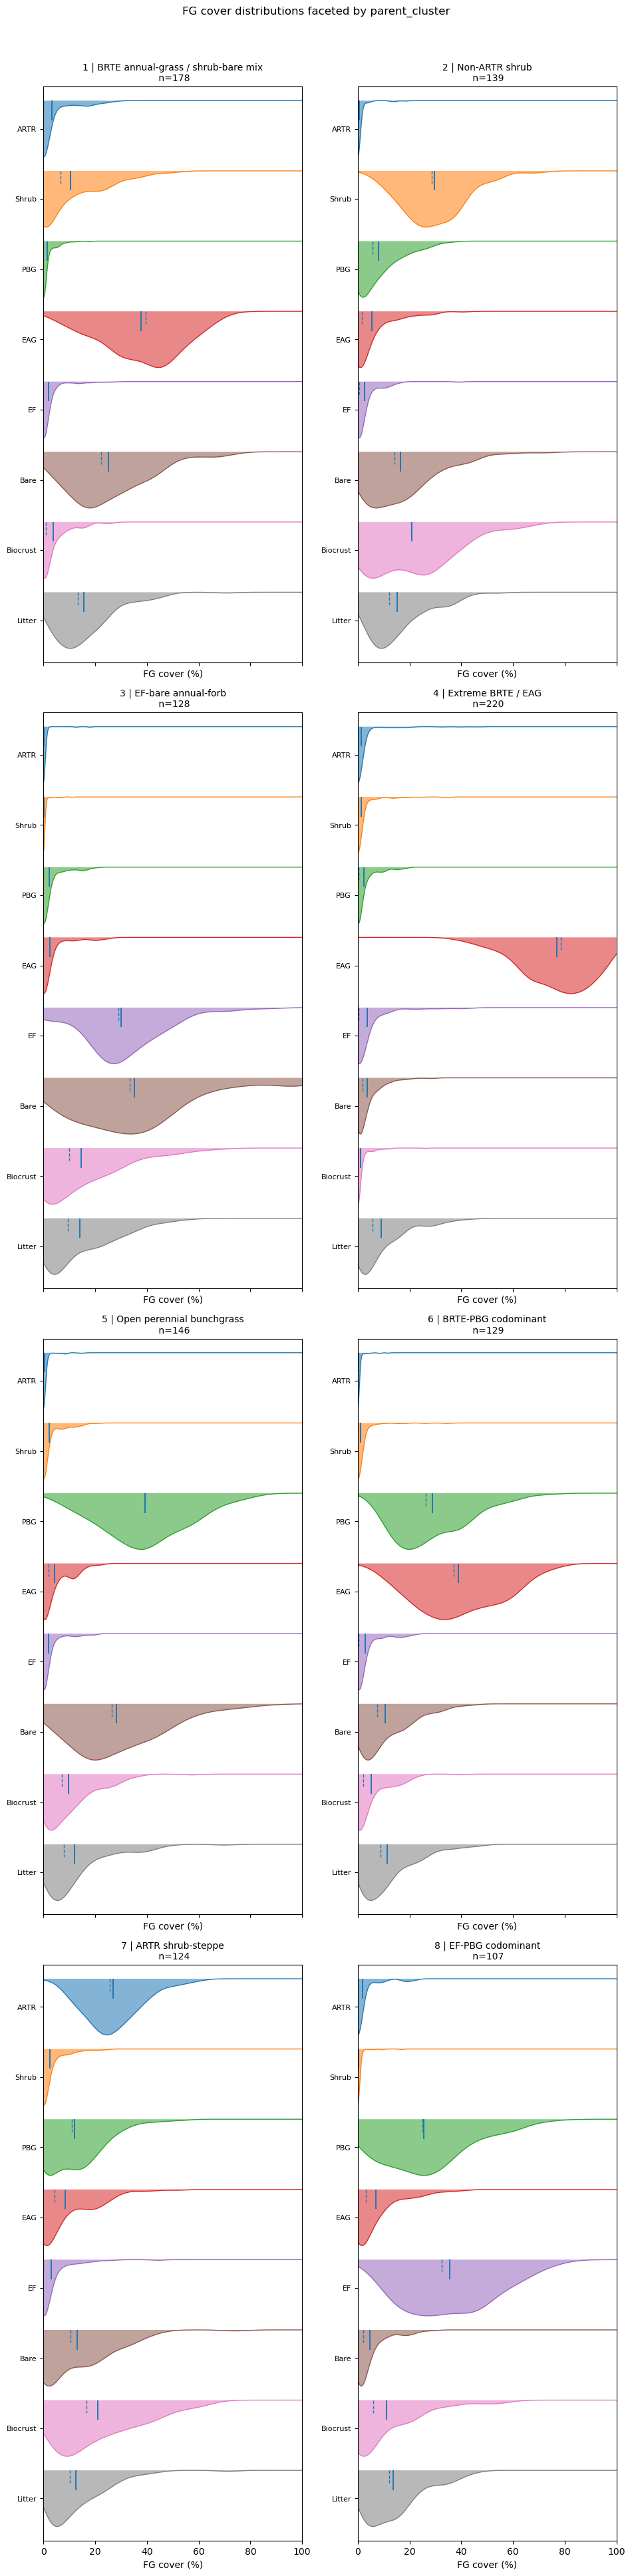

In [67]:
faceted_cluster_ridges(
    data=veg_states,
    cluster_col="parent_cluster",
    label_col="parent_label",
    fg_cols=FG_ORDER,
    ncols=2,
    panels_per_fig=8
)

In [68]:
# =============================================================================
# SUPERIMPOSED POSITIVE RIDGE / DENSITY PLOTS BY PARENT CLUSTER
# =============================================================================

import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


RIDGE_FGS = [
    "ARTR_FG",
    "SHRUB_FG",
    "PBG_FG",
    "EAG_FG",
    "EF_FG",
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "LITTER_FG",
]

FG_LABELS = {
    "ARTR_FG": "ARTR",
    "SHRUB_FG": "Shrub",
    "PBG_FG": "PBG",
    "EAG_FG": "EAG",
    "EF_FG": "EF",
    "BAREGROUND_FG": "Bare",
    "BIOCRUST_FG": "Biocrust",
    "LITTER_FG": "Litter",
}


def faceted_superimposed_fg_ridges(
    data,
    cluster_col="parent_cluster",
    label_col="parent_label",
    fg_cols=RIDGE_FGS,
    xlim=(0, 100),
    ncols=2,
    panels_per_fig=8,
    bandwidth=None,
    normalize_each_fg=True,
    min_unique_for_kde=3,
    alpha_fill=0.28,
    alpha_line=0.95,
    show_mean=True,
):
    """
    One subplot per cluster.
    Within each subplot, FG cover distributions are overlaid as positive densities.
    """

    plot_df = data.copy()

    if cluster_col == "state_id" and "state_type" in plot_df.columns:
        plot_df = plot_df[
            plot_df["state_type"] == "vegetation_state"
        ].copy()

    cluster_vals = sorted(plot_df[cluster_col].dropna().unique())
    x_grid = np.linspace(xlim[0], xlim[1], 500)

    for start in range(0, len(cluster_vals), panels_per_fig):

        current_clusters = cluster_vals[start:start + panels_per_fig]
        n_panels = len(current_clusters)
        nrows = math.ceil(n_panels / ncols)

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(6.2 * ncols, 4.3 * nrows),
            sharex=True,
            sharey=True
        )

        axes = np.atleast_1d(axes).ravel()

        for ax, cluster_val in zip(axes, current_clusters):

            sub = plot_df[
                plot_df[cluster_col] == cluster_val
            ].copy()

            max_y_seen = 0

            for fg in fg_cols:

                values = (
                    sub[fg]
                    .dropna()
                    .astype(float)
                    .to_numpy()
                )

                if len(values) >= 2 and len(np.unique(values)) >= min_unique_for_kde:

                    kde = gaussian_kde(values, bw_method=bandwidth)
                    density = kde(x_grid)

                    if normalize_each_fg and density.max() > 0:
                        density = density / density.max()

                    max_y_seen = max(max_y_seen, density.max())

                    ax.fill_between(
                        x_grid,
                        0,
                        density,
                        alpha=alpha_fill,
                        label=FG_LABELS.get(fg, fg)
                    )

                    ax.plot(
                        x_grid,
                        density,
                        linewidth=1.5,
                        alpha=alpha_line
                    )

                    if show_mean:
                        ax.axvline(
                            values.mean(),
                            ymin=0.0,
                            ymax=0.18,
                            linewidth=1.2,
                            alpha=0.9
                        )

                elif len(values) > 0:
                    # fallback if KDE is not appropriate
                    ax.axvline(
                        values.mean(),
                        linewidth=1.2,
                        alpha=0.9,
                        label=FG_LABELS.get(fg, fg)
                    )

            if label_col is not None:
                cluster_label = sub[label_col].iloc[0]
                title = f"{cluster_val} | {cluster_label}\n n={len(sub)}"
            else:
                title = f"{cluster_val}\n n={len(sub)}"

            ax.set_title(title, fontsize=10)
            ax.set_xlim(*xlim)
            ax.set_ylim(0, max(1.05, max_y_seen * 1.05))
            ax.set_xlabel("FG cover (%)")
            ax.set_ylabel("Relative density")

        for ax in axes[n_panels:]:
            ax.axis("off")

        # single legend for whole figure
        handles, labels = axes[0].get_legend_handles_labels()
        by_label = dict(zip(labels, handles))

        fig.legend(
            by_label.values(),
            by_label.keys(),
            loc="upper center",
            ncol=4,
            frameon=False,
            bbox_to_anchor=(0.5, 1.02)
        )

        fig.suptitle(
            f"Superimposed FG cover distributions faceted by {cluster_col}",
            y=1.08,
            fontsize=13
        )

        plt.tight_layout()
        plt.show()

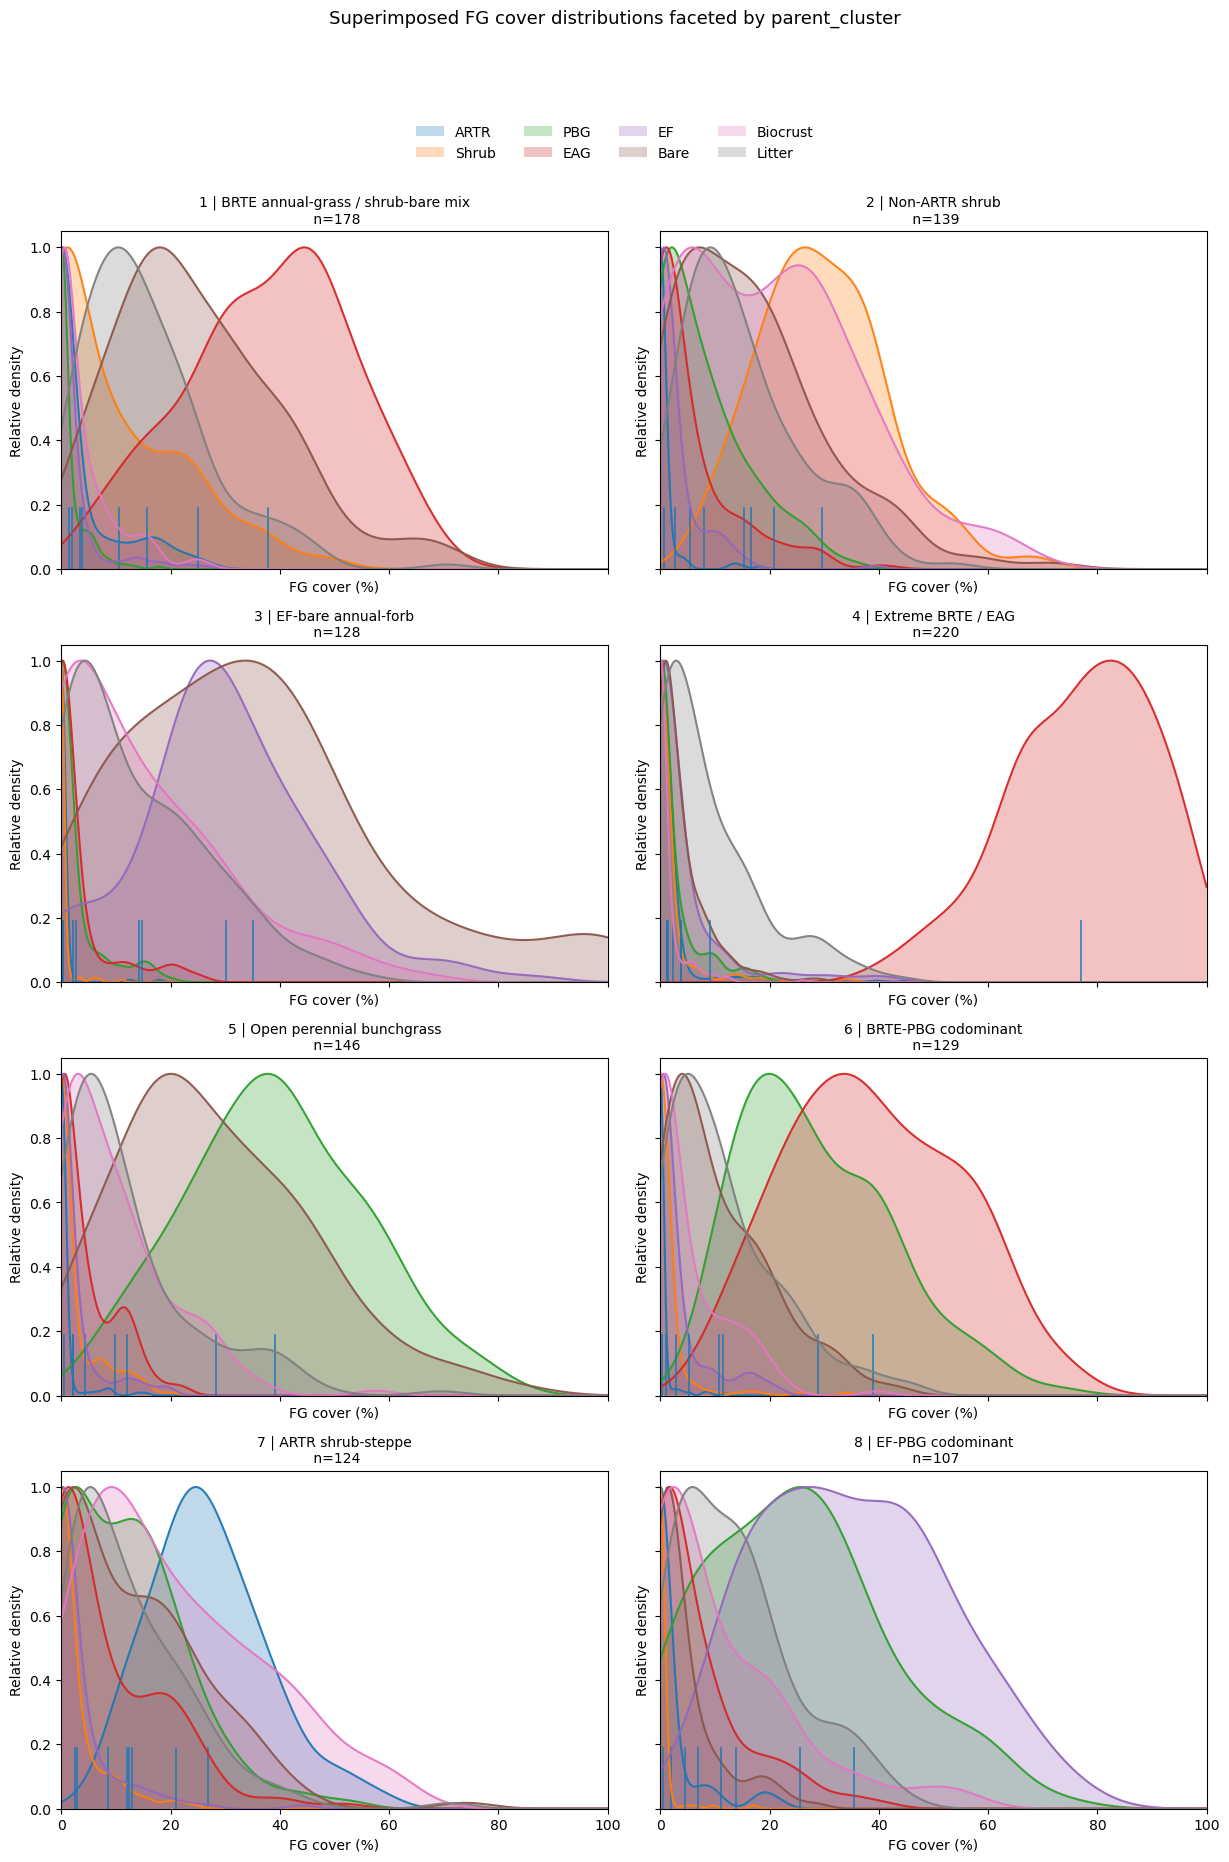

In [69]:
faceted_superimposed_fg_ridges(
    data=veg_states,
    cluster_col="parent_cluster",
    label_col="parent_label"
)

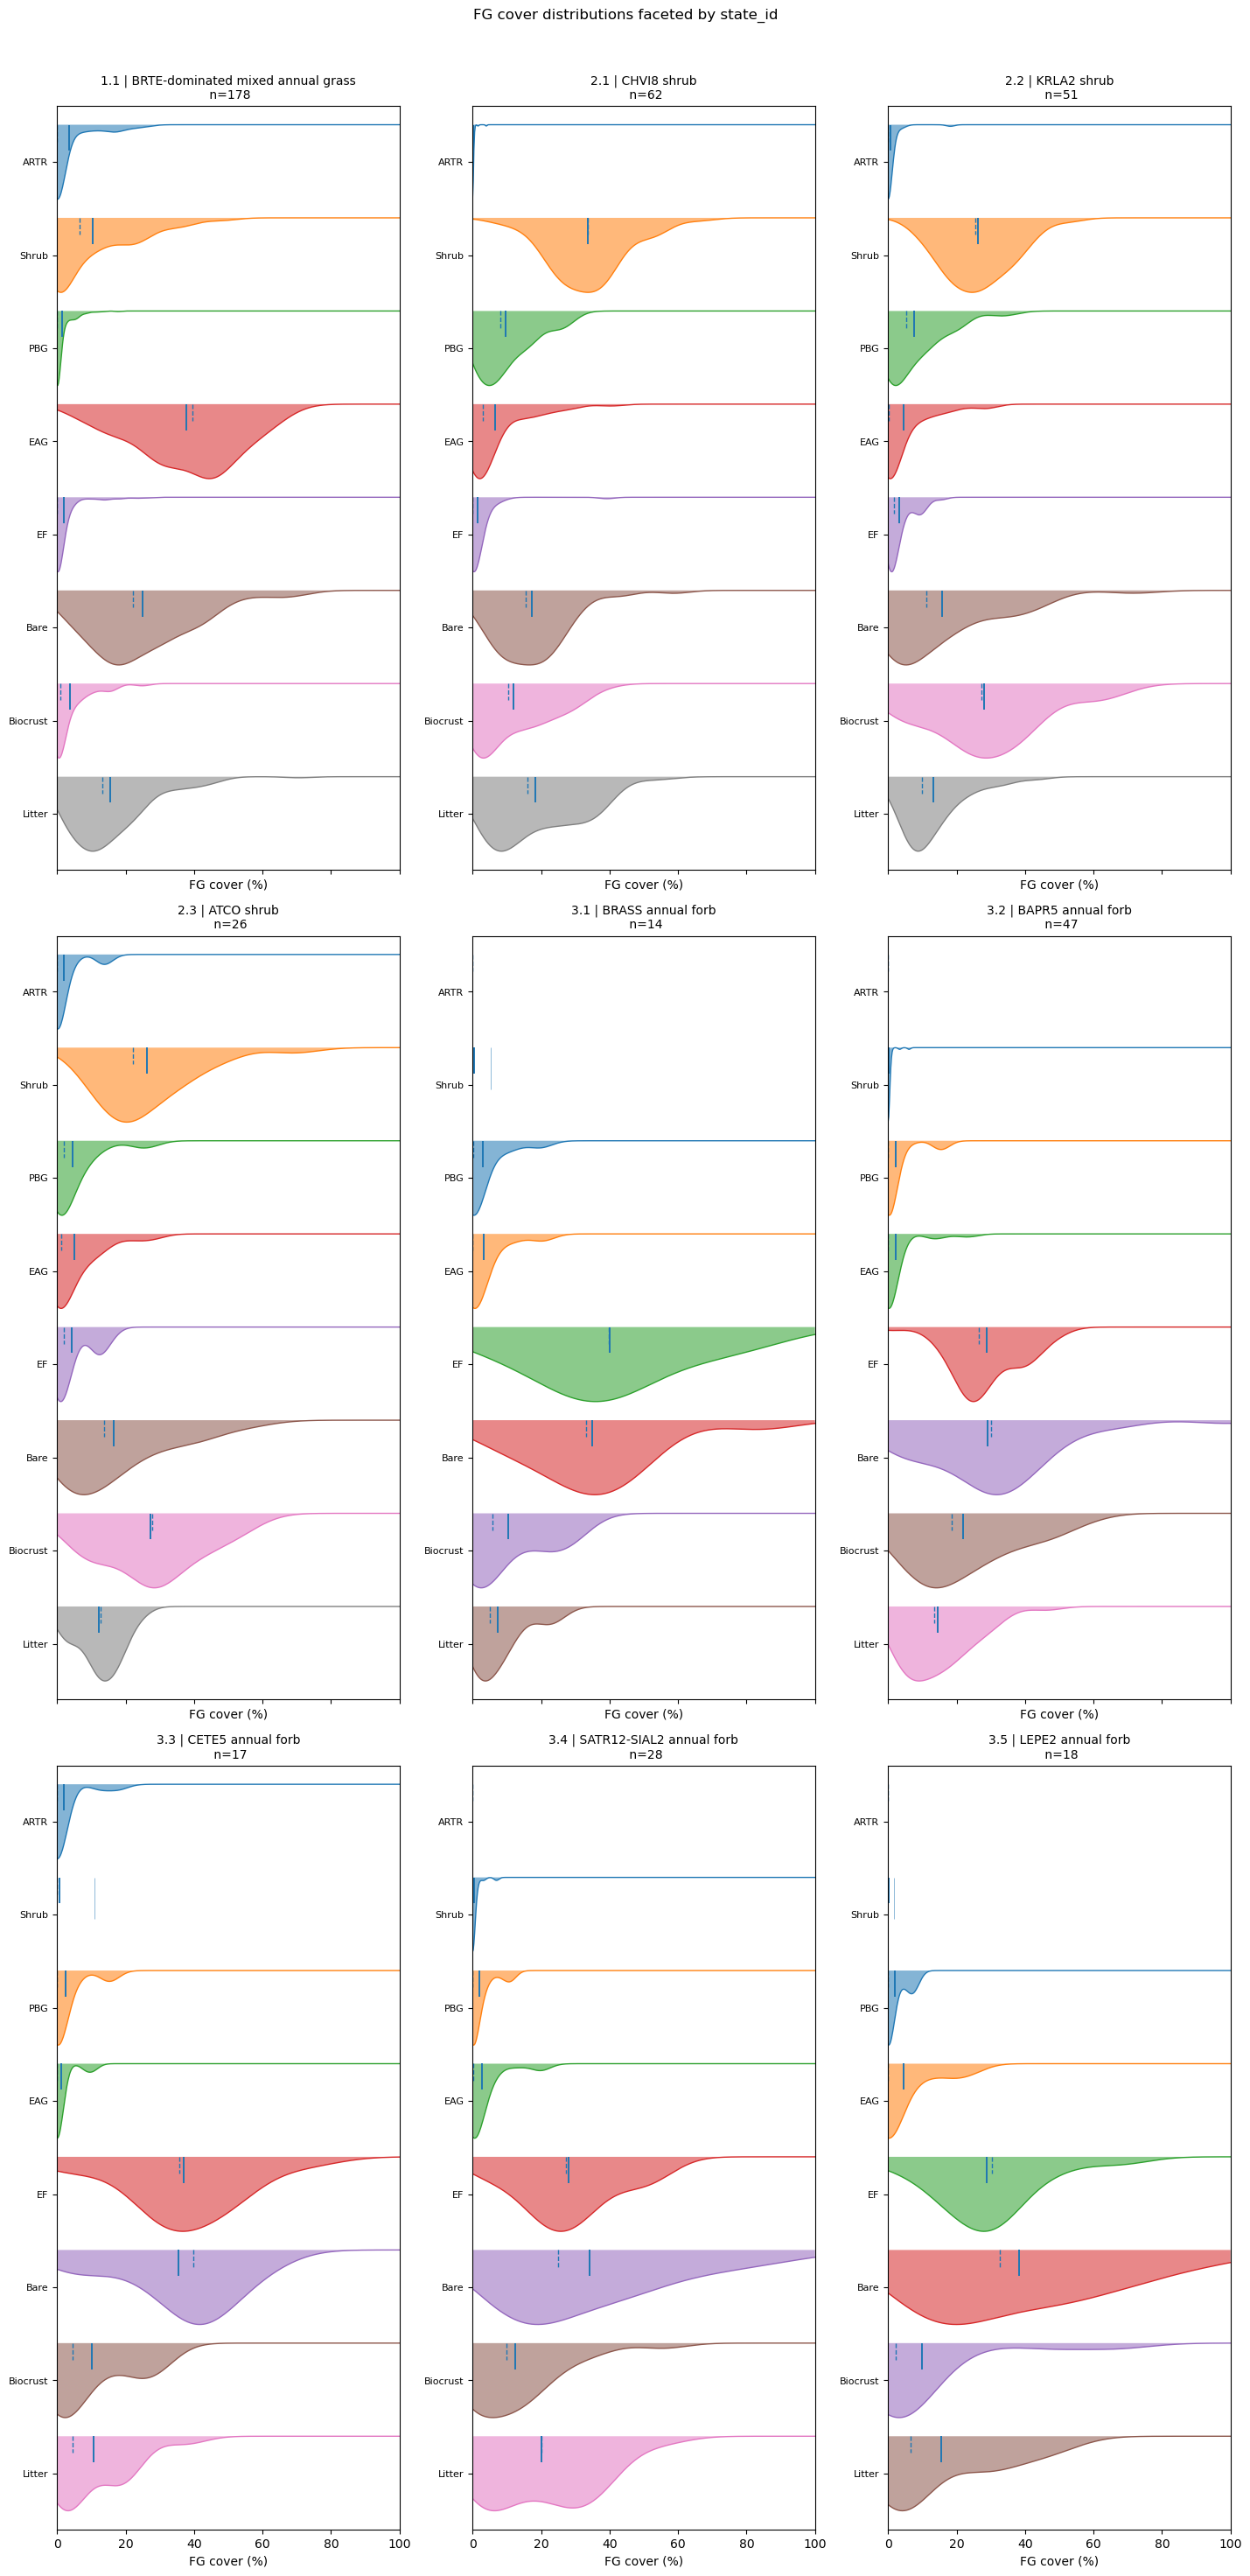

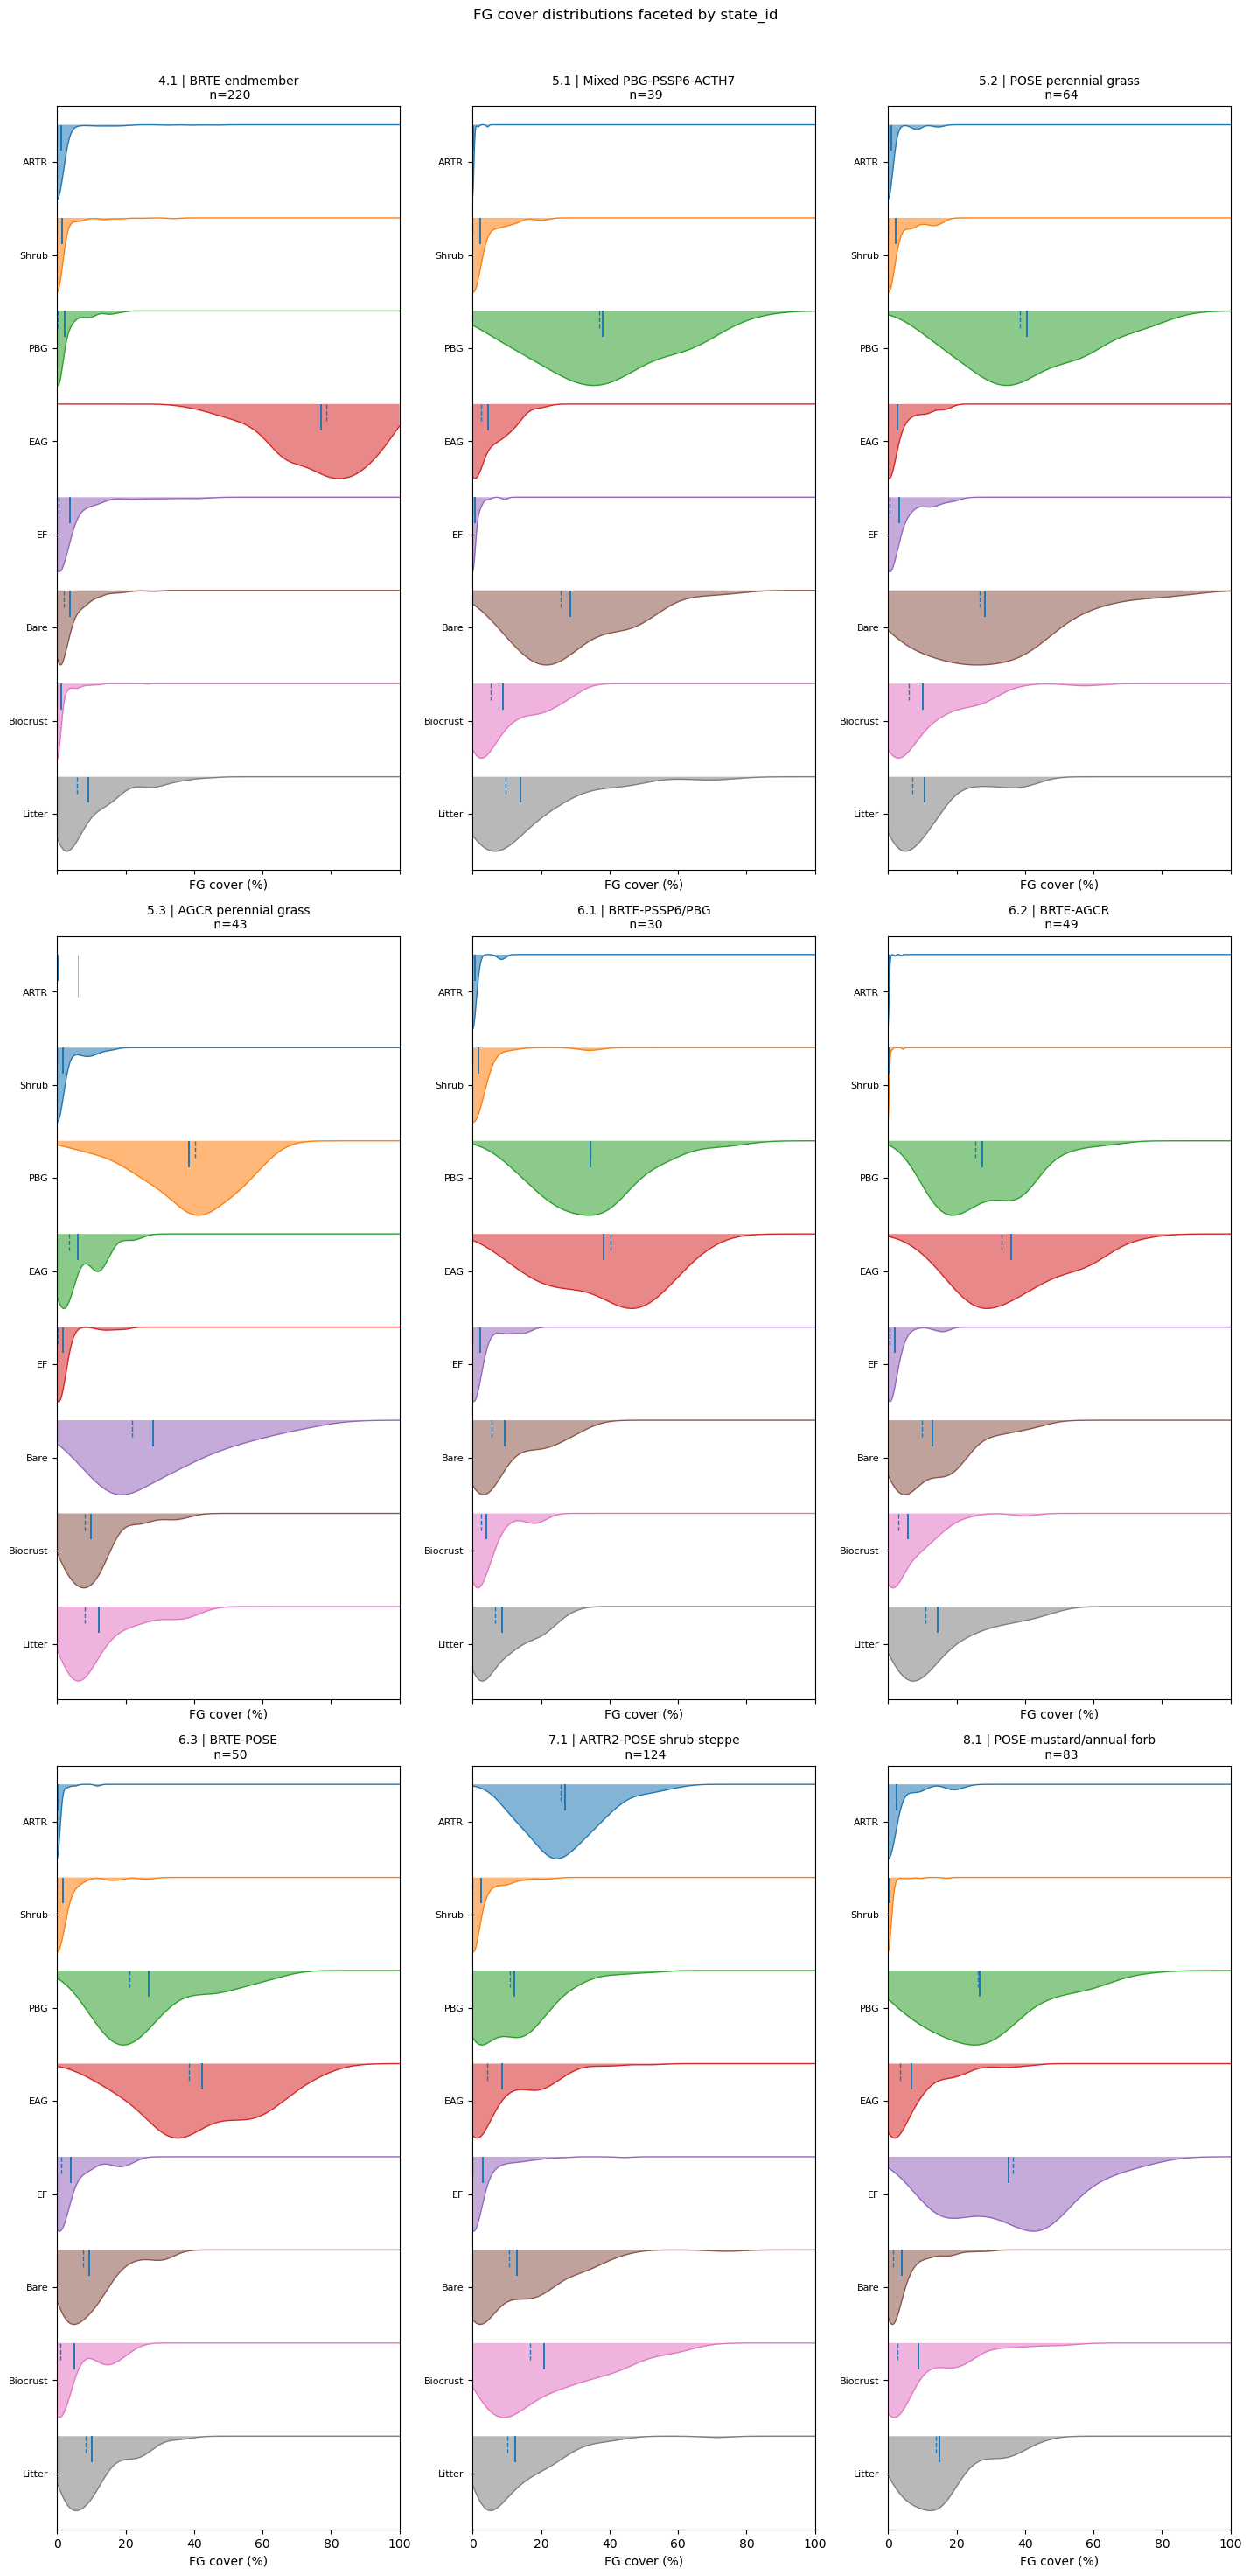

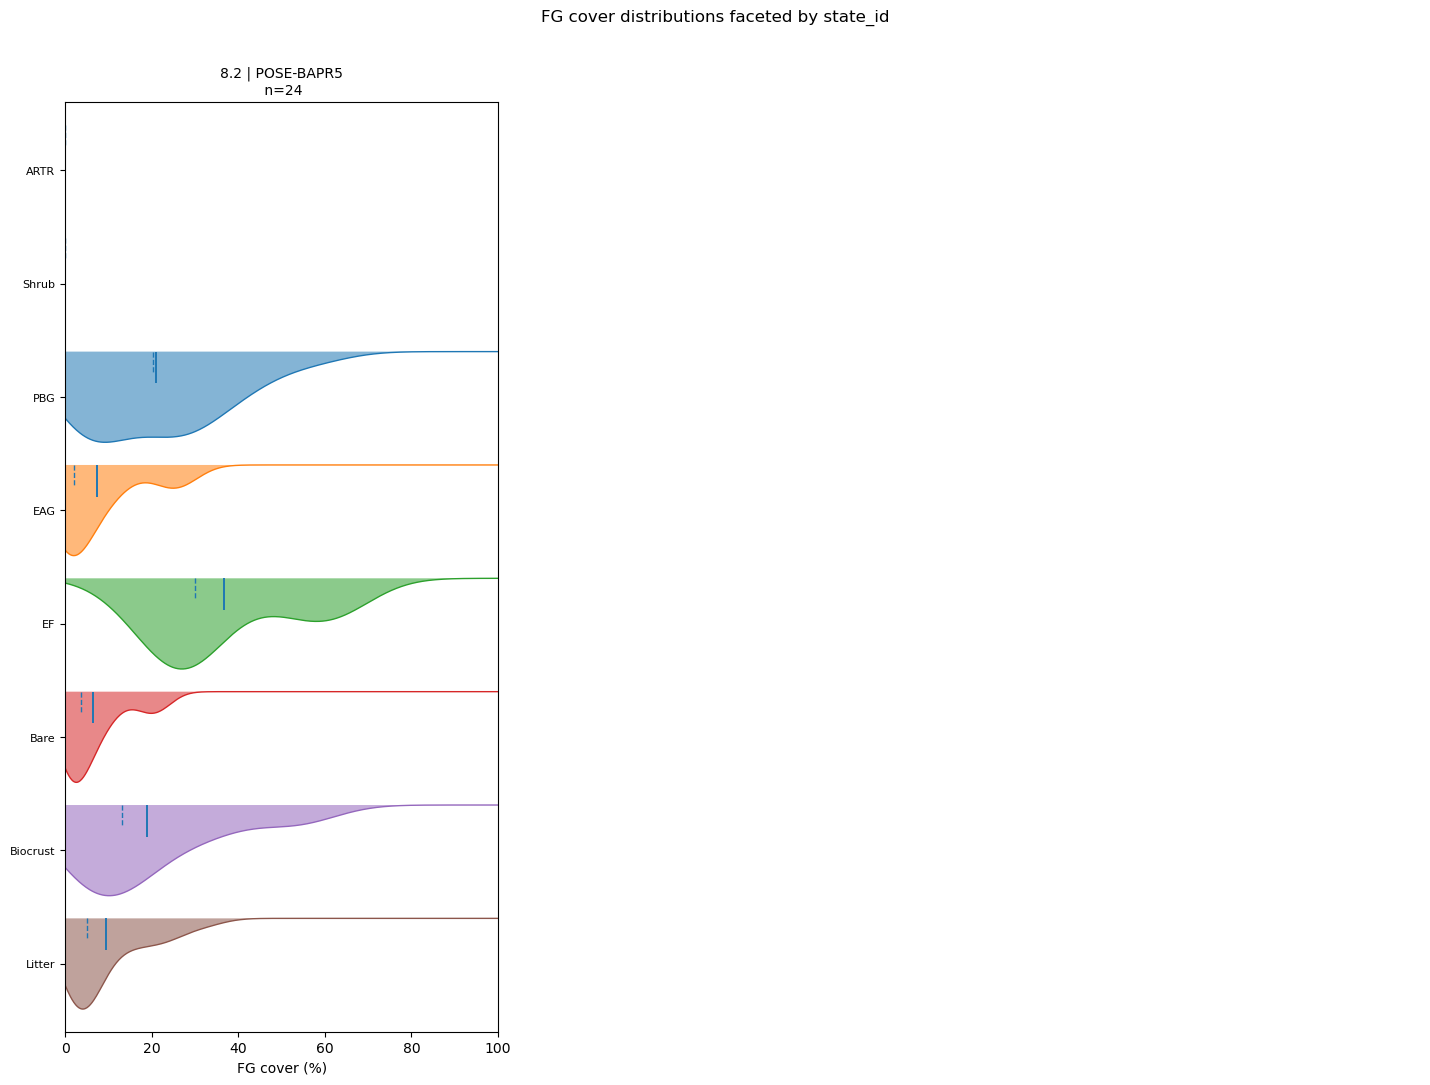

In [70]:
faceted_cluster_ridges(
    data=veg_states,
    cluster_col="state_id",
    label_col="state_label",
    fg_cols=FG_ORDER,
    ncols=3,
    panels_per_fig=9
)

In [71]:
# =============================================================================
# FACETED HORIZONTAL VIOLIN PLOTS BY PARENT CLUSTER
# =============================================================================

import math
import numpy as np
import matplotlib.pyplot as plt

PLOT_FGS = [
    "ARTR_FG",
    "SHRUB_FG",
    "PBG_FG",
    "EAG_FG",
    "EF_FG",
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "LITTER_FG",
]

FG_LABELS = {
    "ARTR_FG": "ARTR",
    "SHRUB_FG": "Shrub",
    "PBG_FG": "PBG",
    "EAG_FG": "EAG",
    "EF_FG": "EF",
    "BAREGROUND_FG": "Bare",
    "BIOCRUST_FG": "Biocrust",
    "LITTER_FG": "Litter",
}


def _sort_cluster_values(values):
    def _key(v):
        s = str(v)
        try:
            return (0, float(s))
        except:
            return (1, s)
    return sorted(values, key=_key)


def faceted_cluster_violins(
    data,
    cluster_col="parent_cluster",
    label_col="parent_label",
    fg_cols=PLOT_FGS,
    xlim=(0, 100),
    ncols=2,
    panels_per_fig=8,
    widths=0.85,
    show_means=True,
    show_medians=True,
):
    """
    One subplot per cluster.
    Within each subplot, one horizontal violin per FG.
    """

    plot_df = data.copy()

    if cluster_col == "state_id" and "state_type" in plot_df.columns:
        plot_df = plot_df[
            plot_df["state_type"] == "vegetation_state"
        ].copy()

    cluster_vals = _sort_cluster_values(
        plot_df[cluster_col].dropna().unique().tolist()
    )

    for start in range(0, len(cluster_vals), panels_per_fig):

        current_clusters = cluster_vals[start:start + panels_per_fig]
        n_panels = len(current_clusters)
        nrows = math.ceil(n_panels / ncols)

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(6.3 * ncols, 4.2 * nrows),
            sharex=True
        )

        axes = np.atleast_1d(axes).ravel()

        for ax, cluster_val in zip(axes, current_clusters):

            sub = plot_df[
                plot_df[cluster_col] == cluster_val
            ].copy()

            datasets = []
            valid_fg_labels = []

            for fg in fg_cols:
                vals = (
                    sub[fg]
                    .dropna()
                    .astype(float)
                    .to_numpy()
                )
                datasets.append(vals)
                valid_fg_labels.append(FG_LABELS.get(fg, fg))

            positions = np.arange(len(fg_cols), 0, -1)

            vp = ax.violinplot(
                datasets,
                positions=positions,
                vert=False,
                widths=widths,
                showmeans=False,
                showmedians=False,
                showextrema=False
            )

            # Light styling
            for body in vp["bodies"]:
                body.set_alpha(0.6)
                body.set_linewidth(0.8)

            # Add means and medians explicitly
            for pos, vals in zip(positions, datasets):

                if len(vals) == 0:
                    continue

                if show_means:
                    ax.scatter(
                        np.mean(vals),
                        pos,
                        s=18,
                        zorder=3
                    )

                if show_medians:
                    ax.vlines(
                        np.median(vals),
                        pos - 0.18,
                        pos + 0.18,
                        linewidth=1.2,
                        linestyles="--",
                        zorder=3
                    )

            if label_col is not None:
                cluster_label = sub[label_col].iloc[0]
                title = f"{cluster_val} | {cluster_label}\n n={len(sub)}"
            else:
                title = f"{cluster_val}\n n={len(sub)}"

            ax.set_title(title, fontsize=10)
            ax.set_yticks(positions)
            ax.set_yticklabels(valid_fg_labels)
            ax.set_xlim(*xlim)
            ax.set_xlabel("FG cover (%)")
            ax.set_ylabel("")

        for ax in axes[n_panels:]:
            ax.axis("off")

        fig.suptitle(
            f"FG cover distributions faceted by {cluster_col}",
            y=1.01,
            fontsize=12
        )

        plt.tight_layout()
        plt.show()

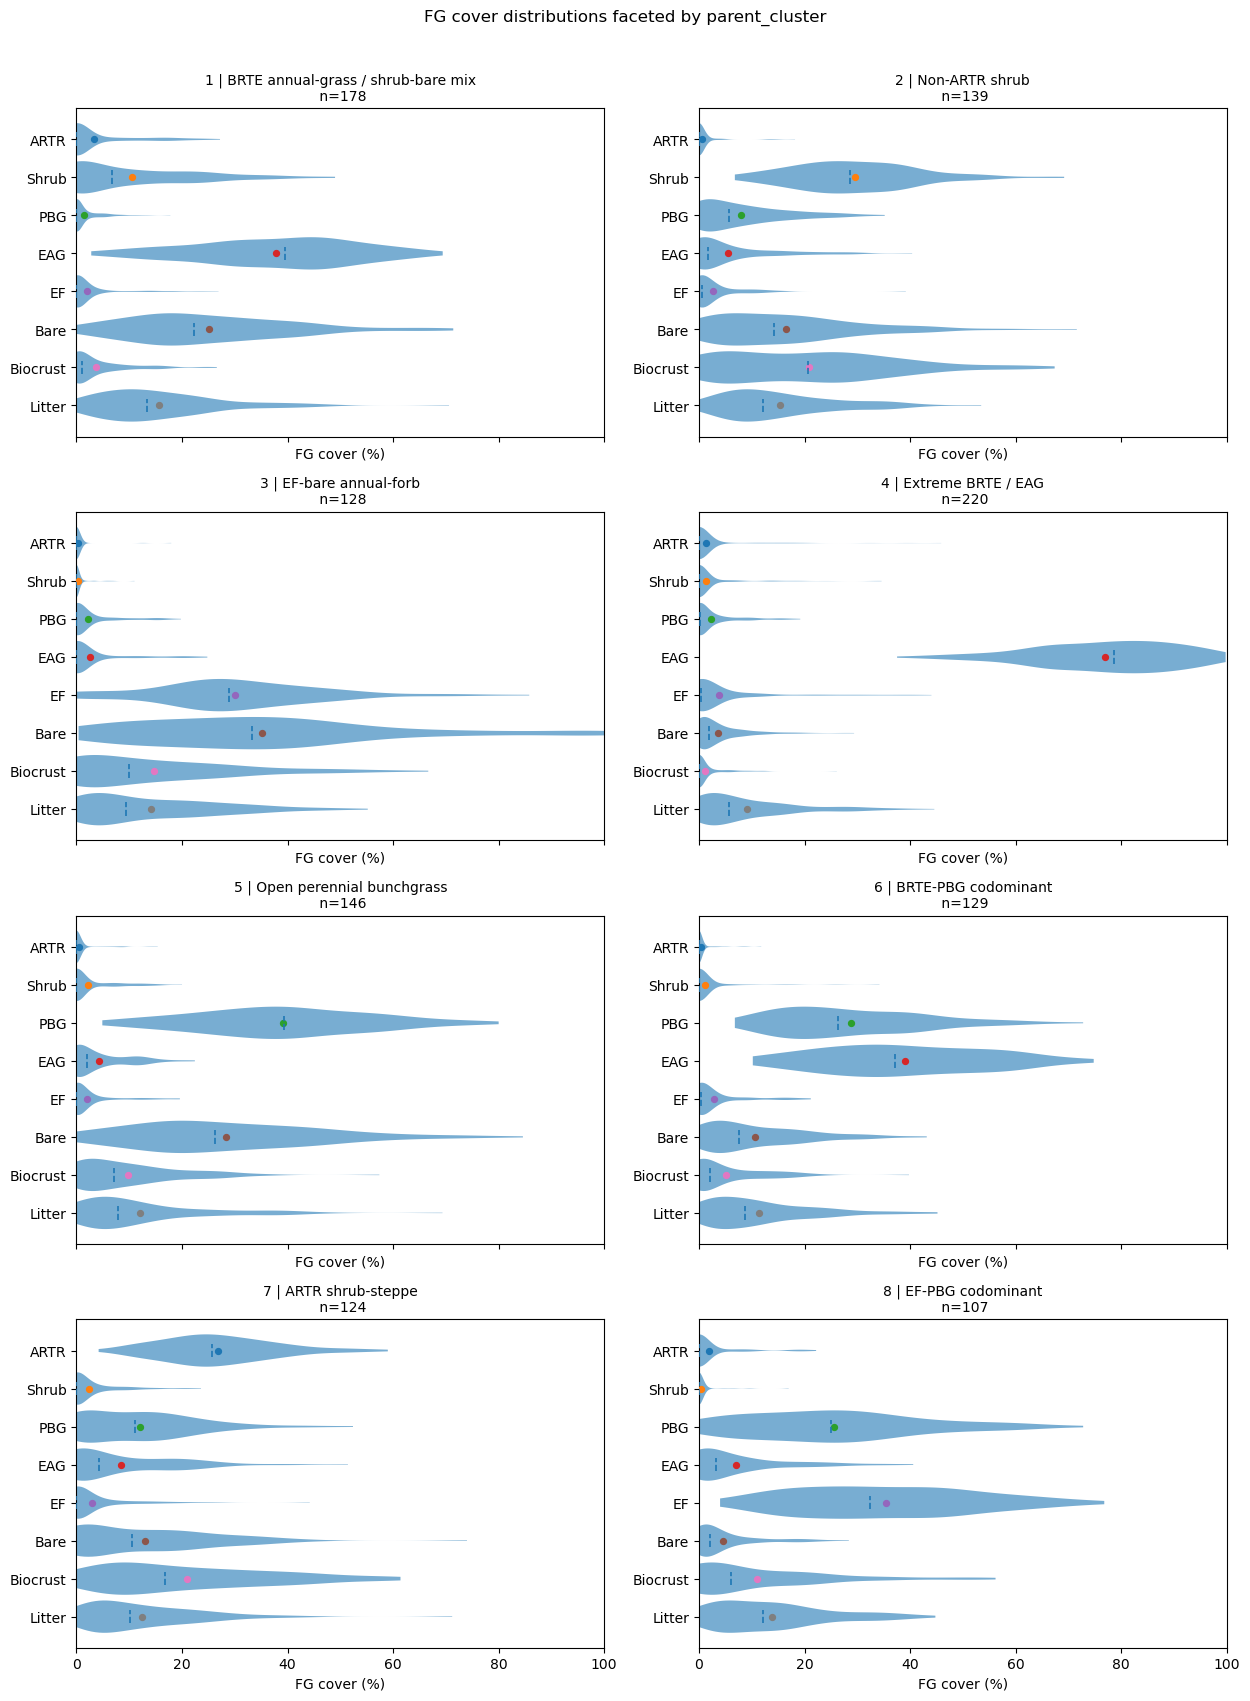

In [72]:
faceted_cluster_violins(
    data=veg_states,
    cluster_col="parent_cluster",
    label_col="parent_label"
)

In [73]:
# =============================================================================
# ENTERKINE-STYLE RIDGELINE WITH OKABE-ITO PALETTE
# AND MEAN LINES THAT REACH THE TOP OF THEIR OWN CURVE
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


PLOT_FGS = [
    "ARTR_FG",
    "SHRUB_FG",
    "PBG_FG",
    "EAG_FG",
    "EF_FG",
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "LITTER_FG",
]

FG_LABELS = {
    "ARTR_FG": "ARTR",
    "SHRUB_FG": "Shrub",
    "PBG_FG": "PBG",
    "EAG_FG": "EAG",
    "EF_FG": "EF",
    "BAREGROUND_FG": "Bare",
    "BIOCRUST_FG": "Biocrust",
    "LITTER_FG": "Litter",
}

# Okabe-Ito palette
FG_COLORS = {
    "ARTR_FG": "#0072B2",       # blue
    "SHRUB_FG": "#009E73",      # bluish green
    "PBG_FG": "#56B4E9",        # sky blue
    "EAG_FG": "#D55E00",        # vermillion
    "EF_FG": "#CC79A7",         # reddish purple
    "BAREGROUND_FG": "#E69F00", # orange
    "BIOCRUST_FG": "#F0E442",   # yellow
    "LITTER_FG": "#000000",     # black
}

# Slightly darker line for yellow so it stays visible
FG_LINE_COLORS = FG_COLORS.copy()
FG_LINE_COLORS["BIOCRUST_FG"] = "#B79F00"


def enterkine_style_ridgeline(
    data,
    cluster_col="parent_cluster",
    fg_cols=PLOT_FGS,
    xlim=(0, 100),
    bw_method=0.25,
    ridge_height=0.80,
    alpha_fill=0.28,
    alpha_line=0.95,
    min_unique_for_kde=3,
    show_means=True,
    label_map=None,
    figsize=(12, 10),
):
    """
    One cluster per horizontal row.
    Multiple FG densities are overlaid on the same baseline.
    Mean lines extend to the top of their own ridge.
    """

    plot_df = data.copy()

    if cluster_col == "state_id" and "state_type" in plot_df.columns:
        plot_df = plot_df[
            plot_df["state_type"] == "vegetation_state"
        ].copy()

    cluster_vals = sorted(
        plot_df[cluster_col].dropna().unique().tolist()
    )

    x_grid = np.linspace(xlim[0], xlim[1], 600)

    fig, ax = plt.subplots(figsize=figsize)

    # Put cluster 1 at top
    y_positions = np.arange(len(cluster_vals), 0, -1)

    legend_handles = []
    legend_labels = []

    for y, cluster_val in zip(y_positions, cluster_vals):

        sub = plot_df[
            plot_df[cluster_col] == cluster_val
        ].copy()

        # baseline
        ax.hlines(
            y,
            xlim[0],
            xlim[1],
            linewidth=0.9,
            color="0.75",
            alpha=0.8,
            zorder=1
        )

        for fg in fg_cols:

            values = (
                sub[fg]
                .dropna()
                .astype(float)
                .to_numpy()
            )

            if len(values) < 2 or len(np.unique(values)) < min_unique_for_kde:
                continue

            kde = gaussian_kde(values, bw_method=bw_method)
            density = kde(x_grid)

            if density.max() <= 0:
                continue

            density = density / density.max() * ridge_height
            ridge = y + density

            fill_color = FG_COLORS[fg]
            line_color = FG_LINE_COLORS[fg]

            poly = ax.fill_between(
                x_grid,
                y,
                ridge,
                facecolor=fill_color,
                edgecolor="none",
                alpha=alpha_fill,
                zorder=2,
                label=FG_LABELS.get(fg, fg)
            )

            ax.plot(
                x_grid,
                ridge,
                color=line_color,
                linewidth=1.25,
                alpha=alpha_line,
                zorder=3
            )

            if show_means:
                mean_x = values.mean()

                # Interpolate the ridge height at the mean x-position
                mean_top = np.interp(mean_x, x_grid, ridge)

                ax.vlines(
                    mean_x,
                    y,
                    mean_top,
                    color=line_color,
                    linewidth=1.4,
                    zorder=4
                )

            label = FG_LABELS.get(fg, fg)
            if label not in legend_labels:
                legend_handles.append(poly)
                legend_labels.append(label)

    if label_map is None:
        yticklabels = [str(v) for v in cluster_vals]
    else:
        yticklabels = [
            f"{v}  {label_map.get(v, '')}".rstrip()
            for v in cluster_vals
        ]

    ax.set_yticks(y_positions)
    ax.set_yticklabels(yticklabels)

    ax.set_xlim(*xlim)
    ax.set_ylim(0.5, len(cluster_vals) + 1.0)

    ax.set_xlabel("Percent cover")
    ax.set_ylabel("Parent cluster")
    ax.set_title("FG cover distributions by parent cluster")

    ax.legend(
        legend_handles,
        legend_labels,
        title="FG",
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5)
    )

    plt.tight_layout()
    plt.show()

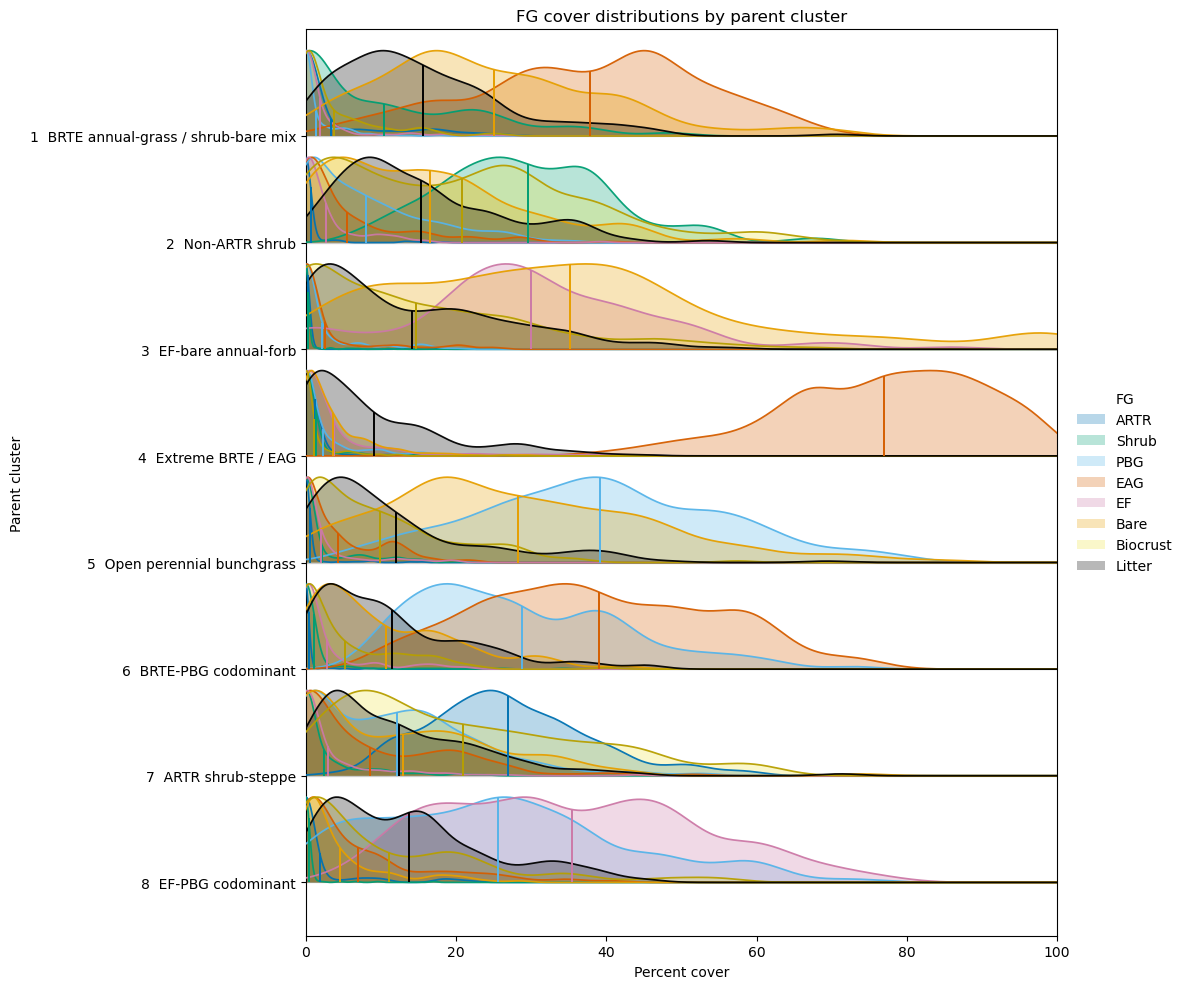

In [74]:
parent_label_map = (
    veg_states[
        ["parent_cluster", "parent_label"]
    ]
    .drop_duplicates()
    .set_index("parent_cluster")["parent_label"]
    .to_dict()
)

enterkine_style_ridgeline(
    data=veg_states,
    cluster_col="parent_cluster",
    fg_cols=PLOT_FGS,
    bw_method=0.25,
    ridge_height=0.80,
    alpha_fill=0.28,
    label_map=parent_label_map,
    figsize=(12, 10)
)

In [75]:
# =============================================================================
# RETAIN FGs WITH OBSERVED PARENT MEAN > 10%
# =============================================================================

PLOT_FGS = [
    "ARTR_FG",
    "SHRUB_FG",
    "PBG_FG",
    "EAG_FG",
    "EF_FG",
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "LITTER_FG",
]

FG_LABELS = {
    "ARTR_FG": "ARTR",
    "SHRUB_FG": "Shrub",
    "PBG_FG": "PBG",
    "EAG_FG": "EAG",
    "EF_FG": "EF",
    "BAREGROUND_FG": "Bare",
    "BIOCRUST_FG": "Biocrust",
    "LITTER_FG": "Litter",
}

parent_fg_means = (
    veg_states
    .groupby("parent_cluster")[PLOT_FGS]
    .mean()
)

retain_by_parent = {
    parent: row[row > 10].index.tolist()
    for parent, row in parent_fg_means.iterrows()
}

for parent, fgs in retain_by_parent.items():
    print(f"\nParent {parent}")
    for fg in fgs:
        print(f"  {FG_LABELS[fg]}: {parent_fg_means.loc[parent, fg]:.1f}")


Parent 1
  Shrub: 10.5
  EAG: 37.8
  Bare: 25.1
  Litter: 15.6

Parent 2
  Shrub: 29.6
  Bare: 16.5
  Biocrust: 20.8
  Litter: 15.3

Parent 3
  EF: 30.0
  Bare: 35.1
  Biocrust: 14.7
  Litter: 14.1

Parent 4
  EAG: 77.0

Parent 5
  PBG: 39.2
  Bare: 28.3
  Litter: 12.0

Parent 6
  PBG: 28.8
  EAG: 39.0
  Bare: 10.7
  Litter: 11.5

Parent 7
  ARTR: 26.9
  PBG: 12.1
  Bare: 13.0
  Biocrust: 20.9
  Litter: 12.5

Parent 8
  PBG: 25.5
  EF: 35.4
  Biocrust: 11.1
  Litter: 13.8


In [76]:
# =============================================================================
# ENTERKINE-STYLE RIDGELINE
# RETAIN ONLY FGs WITH PARENT MEAN > threshold
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


FG_COLORS = {
    "ARTR_FG": "#0072B2",       # blue
    "SHRUB_FG": "#009E73",      # bluish green
    "PBG_FG": "#56B4E9",        # sky blue
    "EAG_FG": "#D55E00",        # vermillion
    "EF_FG": "#CC79A7",         # reddish purple
    "BAREGROUND_FG": "#E69F00", # orange
    "BIOCRUST_FG": "#F0E442",   # yellow
    "LITTER_FG": "#000000",     # black
}

FG_LINE_COLORS = FG_COLORS.copy()
FG_LINE_COLORS["BIOCRUST_FG"] = "#B79F00"


def enterkine_style_ridgeline_filtered(
    data,
    cluster_col="parent_cluster",
    fg_cols=PLOT_FGS,
    mean_threshold=10,
    xlim=(0, 100),
    bw_method=0.25,
    ridge_height=0.80,
    alpha_fill=0.28,
    alpha_line=0.95,
    min_unique_for_kde=3,
    label_map=None,
    figsize=(12, 10),
):
    """
    One cluster per horizontal row.
    Only plot FG distributions whose mean within that cluster exceeds threshold.
    Mean lines extend to the top of each FG curve.
    """

    plot_df = data.copy()

    cluster_vals = sorted(
        plot_df[cluster_col].dropna().unique().tolist()
    )

    # observed means by cluster
    cluster_fg_means = (
        plot_df
        .groupby(cluster_col)[fg_cols]
        .mean()
    )

    x_grid = np.linspace(xlim[0], xlim[1], 600)

    fig, ax = plt.subplots(figsize=figsize)

    y_positions = np.arange(len(cluster_vals), 0, -1)

    legend_handles = []
    legend_labels = []

    for y, cluster_val in zip(y_positions, cluster_vals):

        sub = plot_df[
            plot_df[cluster_col] == cluster_val
        ].copy()

        # retain only FGs above threshold for this cluster
        retained = [
            fg for fg in fg_cols
            if cluster_fg_means.loc[cluster_val, fg] > mean_threshold
        ]

        ax.hlines(
            y,
            xlim[0],
            xlim[1],
            linewidth=0.9,
            color="0.75",
            alpha=0.8,
            zorder=1
        )

        for fg in retained:

            values = (
                sub[fg]
                .dropna()
                .astype(float)
                .to_numpy()
            )

            if len(values) < 2 or len(np.unique(values)) < min_unique_for_kde:
                continue

            kde = gaussian_kde(values, bw_method=bw_method)
            density = kde(x_grid)

            if density.max() <= 0:
                continue

            density = density / density.max() * ridge_height
            ridge = y + density

            fill_color = FG_COLORS[fg]
            line_color = FG_LINE_COLORS[fg]

            poly = ax.fill_between(
                x_grid,
                y,
                ridge,
                facecolor=fill_color,
                edgecolor="none",
                alpha=alpha_fill,
                zorder=2,
                label=FG_LABELS[fg]
            )

            ax.plot(
                x_grid,
                ridge,
                color=line_color,
                linewidth=1.25,
                alpha=alpha_line,
                zorder=3
            )

            mean_x = values.mean()
            mean_top = np.interp(mean_x, x_grid, ridge)

            ax.vlines(
                mean_x,
                y,
                mean_top,
                color=line_color,
                linewidth=1.4,
                zorder=4
            )

            if FG_LABELS[fg] not in legend_labels:
                legend_handles.append(poly)
                legend_labels.append(FG_LABELS[fg])

    if label_map is None:
        yticklabels = [str(v) for v in cluster_vals]
    else:
        yticklabels = [
            f"{v}  {label_map.get(v, '')}".rstrip()
            for v in cluster_vals
        ]

    ax.set_yticks(y_positions)
    ax.set_yticklabels(yticklabels)

    ax.set_xlim(*xlim)
    ax.set_ylim(0.5, len(cluster_vals) + 1.0)

    ax.set_xlabel("Percent cover")
    ax.set_ylabel("Parent cluster")
    ax.set_title(
        f"FG cover distributions by parent cluster\n"
        f"(showing only FGs with mean cover > {mean_threshold}%)"
    )

    ax.legend(
        legend_handles,
        legend_labels,
        title="FG",
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5)
    )

    plt.tight_layout()
    plt.show()

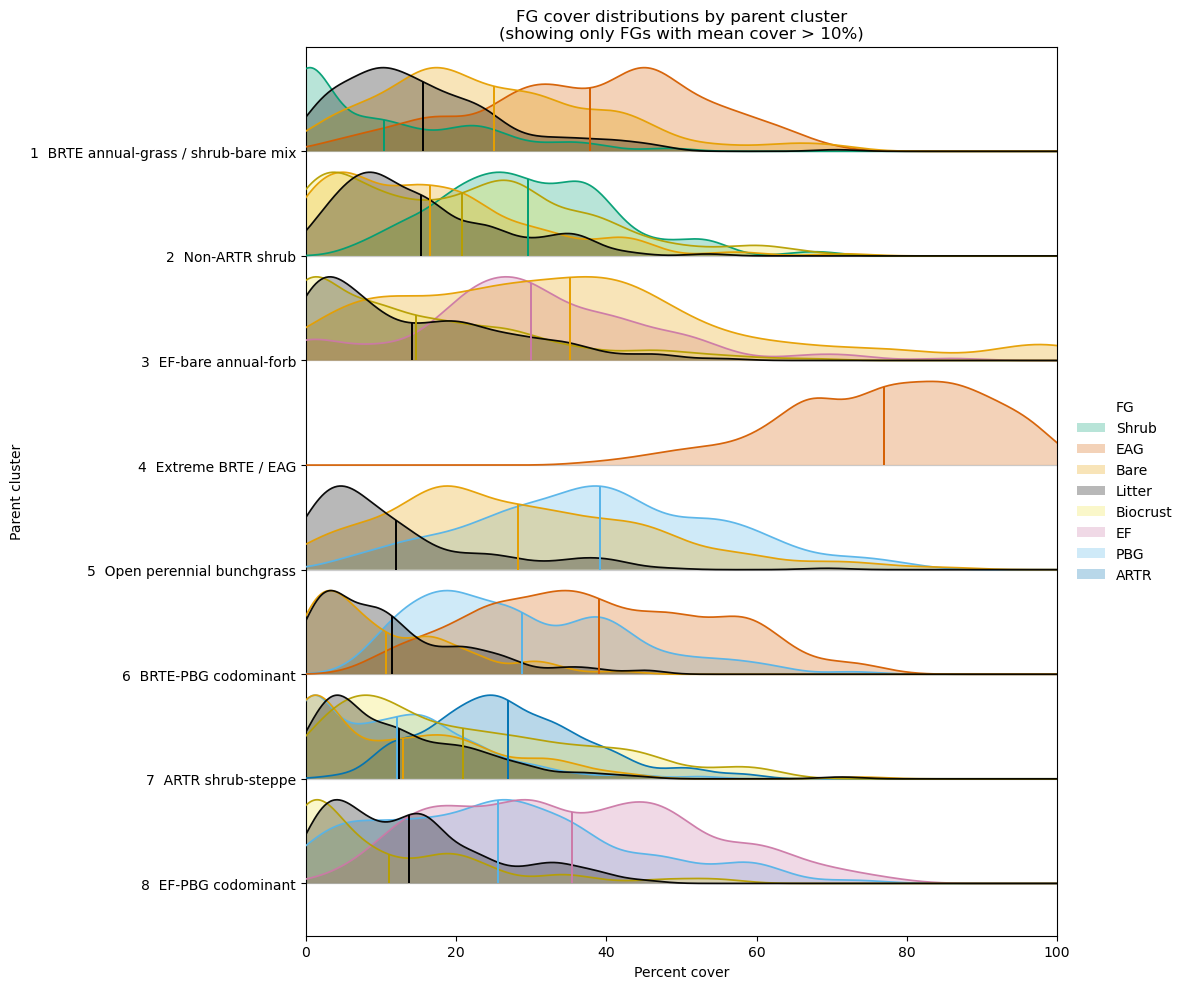

In [77]:
parent_label_map = (
    veg_states[["parent_cluster", "parent_label"]]
    .drop_duplicates()
    .set_index("parent_cluster")["parent_label"]
    .to_dict()
)

enterkine_style_ridgeline_filtered(
    data=veg_states,
    cluster_col="parent_cluster",
    fg_cols=PLOT_FGS,
    mean_threshold=10,
    bw_method=0.25,
    label_map=parent_label_map,
    figsize=(12, 10)
)

## Final FCM diagnostics across \(K\) at fixed \(m=1.33\)

The fuzzifier is fixed at the theoretically selected value \(m=1.33\), and the number of parent clusters is evaluated from \(K=5\) through \(K=15\).

- **Partition coefficient (PC):** measures membership crispness. Higher values indicate observations are assigned more strongly toward individual clusters rather than diffusely across several clusters.
- **Partition entropy (PE):** measures uncertainty in the fuzzy memberships. Lower values indicate less ambiguous cluster assignments.
- **Minimum centroid distance (MCD):** measures the separation of the closest pair of fuzzy cluster centroids. Higher values indicate that even the most similar clusters remain well separated.
- **Xie–Beni index (XB):** balances within-cluster dispersion against separation of the closest centroids. Lower values indicate a more compact and better-separated fuzzy partition.

PC and PE primarily characterize the membership matrix, whereas MCD and XB describe the geometry of the partition. The indices are interpreted jointly rather than treated as independent votes for an optimal \(K\).

In [80]:
# =============================================================================
# FINAL FCM DIAGNOSTIC SWEEP
# K = 5..15 at fixed m = 1.33
# =============================================================================

K_DIAGNOSTIC_VALUES = range(5, 16)
M_DIAGNOSTIC = 1.33

diagnostic_rows = []

for k in K_DIAGNOSTIC_VALUES:

    print(f"Fitting K={k}, m={M_DIAGNOSTIC:.2f} ...")

    fit = fit_fcm_best_of_n(
        X=X,
        k=k,
        m=M_DIAGNOSTIC,
        n_init=N_INIT,
        max_iter=MAX_ITER,
        tol=TOL,
        random_state=RANDOM_STATE,
    )

    U_k = fit["U"]
    centers_k = fit["centers"]

    diagnostic_rows.append({
        "k": k,
        "m": M_DIAGNOSTIC,
        "best_seed": fit["seed"],
        "objective": fit["objective"],
        "iterations": fit["n_iter"],

        "PC": partition_coefficient(U_k),
        "PE": partition_entropy(U_k),

        "MCD": minimum_centroid_distance(
            centers_k
        ),

        "XB": xie_beni_index(
            X=X,
            centers=centers_k,
            U=U_k,
            m=M_DIAGNOSTIC,
        ),
    })


fcm_diagnostics = (
    pd.DataFrame(diagnostic_rows)
    .sort_values("k")
    .reset_index(drop=True)
)


display(
    fcm_diagnostics.style
    .format({
        "m": "{:.2f}",
        "objective": "{:.6f}",
        "PC": "{:.4f}",
        "PE": "{:.4f}",
        "MCD": "{:.4f}",
        "XB": "{:.4f}",
    })
    .hide(axis="index")
)

Fitting K=5, m=1.33 ...
Fitting K=6, m=1.33 ...
Fitting K=7, m=1.33 ...
Fitting K=8, m=1.33 ...
Fitting K=9, m=1.33 ...
Fitting K=10, m=1.33 ...
Fitting K=11, m=1.33 ...
Fitting K=12, m=1.33 ...
Fitting K=13, m=1.33 ...
Fitting K=14, m=1.33 ...
Fitting K=15, m=1.33 ...


k,m,best_seed,objective,iterations,PC,PE,MCD,XB
5,1.33,50,220.049659,66,0.7255,0.5628,0.5514,0.6182
6,1.33,49,201.789211,143,0.6834,0.6521,0.4277,0.9418
7,1.33,59,187.119584,110,0.6734,0.6879,0.4202,0.9049
8,1.33,48,175.176128,165,0.6637,0.7238,0.4830,0.6412
9,1.33,44,164.774720,150,0.6533,0.7559,0.4010,0.8751
10,1.33,51,156.573171,221,0.6523,0.7693,0.3997,0.8369
11,1.33,42,149.489466,198,0.6494,0.7854,0.3826,0.8720
12,1.33,54,143.339614,151,0.6471,0.8013,0.3930,0.7927
13,1.33,43,137.832541,171,0.6491,0.8069,0.3972,0.7460
14,1.33,61,132.731086,130,0.6387,0.8357,0.3738,0.8114


In [82]:

COMBINED_PATH = Path(
    r"C:\NCA_DATA\Vegetation Data\NCA_Master_Aligned_spp_fg_through2026.csv"
)

CLUSTER_DIR = COMBINED_PATH.parent / "Clustering_Veg"

FCM_K_DIAGNOSTICS_PATH = (
    CLUSTER_DIR
    / "FCM_K5_K15_diagnostics_m1p33.csv"
)

fcm_diagnostics.to_csv(
    FCM_K_DIAGNOSTICS_PATH,
    index=False
)

print("Wrote:")
print(FCM_K_DIAGNOSTICS_PATH)

Wrote:
C:\NCA_DATA\Vegetation Data\Clustering_Veg\FCM_K5_K15_diagnostics_m1p33.csv


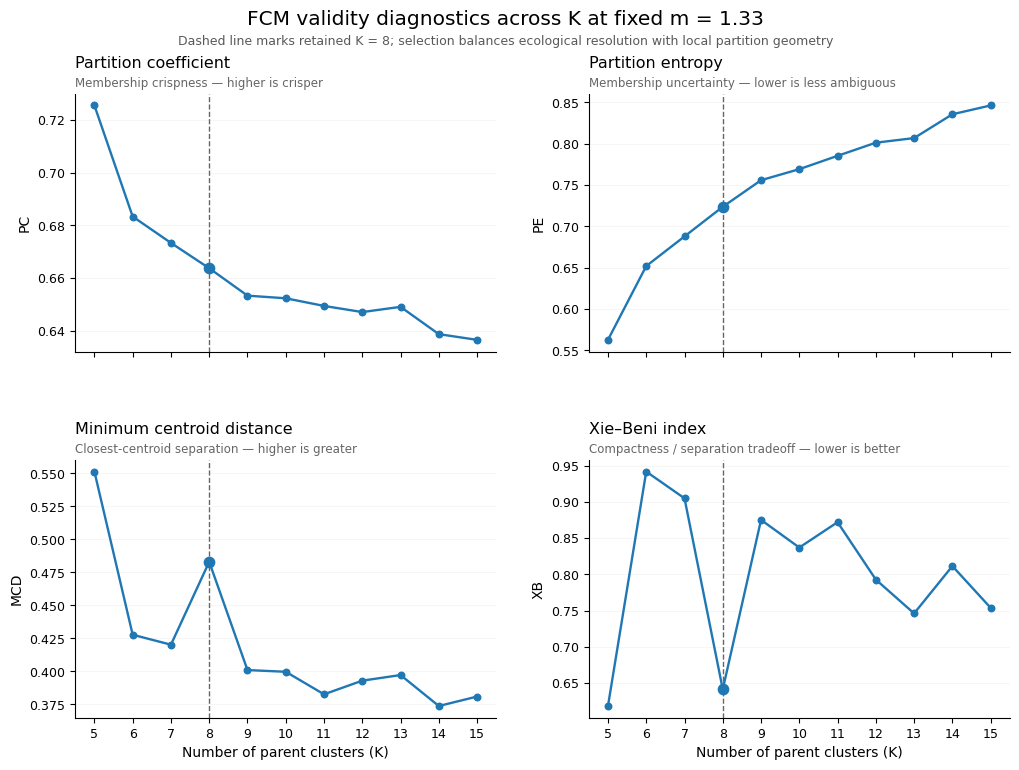

In [85]:
# =============================================================================
# FOUR-PANEL FCM VALIDITY DIAGNOSTICS
# K = 5..15 at fixed m = 1.33
#
# Dashed line = retained K = 8
# K = 8 is retained for ecological resolution + strong local geometry,
# not because every index has its global optimum there.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt


def plot_fcm_diagnostics_clean(
    diagnostics,
    selected_k=8,
    m_value=1.33,
    figsize=(10.5, 8.0),
):

    # -------------------------------------------------------------------------
    # Prepare data
    # -------------------------------------------------------------------------

    df = (
        diagnostics.loc[
            np.isclose(
                diagnostics["m"].astype(float),
                float(m_value)
            )
        ]
        .sort_values("k")
        .reset_index(drop=True)
    )

    if selected_k not in df["k"].values:
        raise ValueError(
            f"K={selected_k} is not present in diagnostics."
        )

    selected = (
        df.loc[df["k"] == selected_k]
        .iloc[0]
    )

    # -------------------------------------------------------------------------
    # Figure
    # -------------------------------------------------------------------------

    fig, axes = plt.subplots(
        2,
        2,
        figsize=figsize,
        sharex=True,
    )

    axes = axes.ravel()

    panels = [
        {
            "metric": "PC",
            "title": "Partition coefficient",
            "blurb": "Membership crispness — higher is crisper",
        },
        {
            "metric": "PE",
            "title": "Partition entropy",
            "blurb": "Membership uncertainty — lower is less ambiguous",
        },
        {
            "metric": "MCD",
            "title": "Minimum centroid distance",
            "blurb": "Closest-centroid separation — higher is greater",
        },
        {
            "metric": "XB",
            "title": "Xie–Beni index",
            "blurb": "Compactness / separation tradeoff — lower is better",
        },
    ]

    # -------------------------------------------------------------------------
    # Panels
    # -------------------------------------------------------------------------

    for ax, spec in zip(axes, panels):

        metric = spec["metric"]

        # Main diagnostic trajectory
        ax.plot(
            df["k"],
            df[metric],
            marker="o",
            linewidth=1.7,
            markersize=4.7,
        )

        # Retained solution
        ax.axvline(
            selected_k,
            linestyle="--",
            linewidth=1.0,
            color="0.40",
            zorder=1,
        )

        ax.scatter(
            selected_k,
            selected[metric],
            s=55,
            zorder=5,
        )

        # ---------------------------------------------------------------------
        # Titles OUTSIDE data area
        # ---------------------------------------------------------------------

        ax.set_title(
            spec["title"],
            loc="left",
            fontsize=11.5,
            pad=19,
        )

        ax.text(
            0.0,
            1.015,
            spec["blurb"],
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=8.5,
            color="0.40",
            clip_on=False,
        )

        # ---------------------------------------------------------------------
        # Axes
        # ---------------------------------------------------------------------

        ax.set_ylabel(
            metric,
            fontsize=10,
        )

        ax.set_xticks(
            np.arange(
                int(df["k"].min()),
                int(df["k"].max()) + 1
            )
        )

        # Horizontal grid only:
        # easier to read the index trajectories without clutter.
        ax.grid(
            axis="y",
            linewidth=0.45,
            alpha=0.18,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.tick_params(
            axis="both",
            labelsize=9,
        )

    # X labels only on bottom row
    axes[2].set_xlabel(
        "Number of parent clusters (K)",
        fontsize=10,
    )

    axes[3].set_xlabel(
        "Number of parent clusters (K)",
        fontsize=10,
    )

    # -------------------------------------------------------------------------
    # Figure-level title and interpretation
    # -------------------------------------------------------------------------

    fig.suptitle(
        f"FCM validity diagnostics across K at fixed m = {m_value:.2f}",
        fontsize=14.5,
        y=0.985,
    )

    fig.text(
        0.5,
        0.945,
        (
            f"Dashed line marks retained K = {selected_k}; "
            "selection balances ecological resolution with local partition geometry"
        ),
        ha="center",
        va="center",
        fontsize=9,
        color="0.35",
    )

   
    # More room between rows prevents titles/subtitles from colliding
    fig.subplots_adjust(
        left=0.09,
        right=0.98,
        bottom=0.10,
        top=0.88,
        wspace=0.22,
        hspace=0.42,
    )

    plt.show()


# =============================================================================
# RUN
# =============================================================================

plot_fcm_diagnostics_clean(
    diagnostics=fcm_diagnostics,
    selected_k=8,
    m_value=1.33,
    figsize=(10.5, 8.0),
)